# Fit-accuracy knobs: stage 1 arms against poly3_total

- Six DR2 galaxies, one switch per arm, one RTX 5060; reference fits from `results/calibration-polynomial-dr2/poly3_total`.
- `seed_rep1..3`: same model, other NSS seeds, two galaxies; sets the scatter floor.
- Scoring: raw chi2 at f_calib = 3% on common pixels, photometric chi2 on common bands, ln Z where the data are identical, parameter shifts in half-width units, Lick and Borghi+22 agreement.
- Verdict rule (fixed before the run): adopt only if an arm beats the seed floor on a physics parameter or improves Lick/Borghi agreement.

In [1]:
import os, sys, json, re, shutil, time
os.environ.setdefault("JAX_PLATFORMS", "cpu")
from pathlib import Path
import h5py
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
import corner
from astropy.table import Table

PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", Path.cwd()))
while not (PROJECT_ROOT / "scripts" / "per_galaxy_diagnostics.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
import per_galaxy_diagnostics as pgd
from build_dr2_quiescent_summary import formation_times
from ceridwen.observation.stellar_indices import StellarIndices, LEGAC_DR2_STELLAR_INDEX_DEFINITIONS

REF_ROOT = PROJECT_ROOT / "results/calibration-polynomial-dr2"
TEST_ROOT = os.environ.get("CERIDWEN_KNOBS_RESULTS")  # scratch tree for test runs; unset in the committed execution
RESULTS = Path(TEST_ROOT) if TEST_ROOT else PROJECT_ROOT / "results/fit-accuracy-knobs"
WIKI_FIGURES = Path(TEST_ROOT) / "wiki" if TEST_ROOT else PROJECT_ROOT / "wiki/analyses/fit-accuracy-knobs"
REF_ARM = "poly3_total"
SEED_ARMS = ["seed_rep1", "seed_rep2", "seed_rep3"]
KNOB_ARMS = ["floor20", "dust_free", "no_irac", "mask_cn", "sfh_cont", "emis_wide"]
MOCK_REF, MOCK_ARM = "mock_tilt4_poly3", "mock_tilt4_sfh_cont"
PHYSICS = ["age", "Z", "afe", "tau_dust", "logmass"]
F_FIXED_PCT = 3.0
COLOURS = {REF_ARM: "k", "seed_rep1": "0.55", "seed_rep2": "0.65", "seed_rep3": "0.75",
           "floor20": "tab:orange", "dust_free": "tab:brown", "no_irac": "tab:purple", "mask_cn": "tab:red",
           "sfh_cont": "tab:green", "emis_wide": "tab:cyan", MOCK_REF: "0.4", MOCK_ARM: "tab:green"}
LABELS = {"logmass": r"$\log_{10}(M_\star/M_\odot)$", "Z": r"$\log_{10} Z$", "afe": r"$[\alpha/\mathrm{Fe}]$",
          "tau_dust": r"$\tau_{\mathrm{dust}}$", "age": r"$t_{\mathrm{MW}}$ [Gyr]", "t50": r"$t_{50}$ [Gyr]",
          "f_calib": r"$f_{\rm calib}$ [%]", "dust_index": r"$\delta_{\rm dust}$"}
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 80); pd.set_option("display.precision", 3)


def _text(v):
    return v.decode() if isinstance(v, bytes) else str(v)


def load_fit(folder):
    out = {"folder": folder}
    with h5py.File(folder / "ceridwen_derived_outputs.h5", "r") as d:
        out["attrs"] = dict(d.attrs)
        names = [_text(v) for v in d["summary/parameter"][:]]
        out["summary"] = pd.DataFrame({"q16": d["summary/q16"][:], "q50": d["summary/q50"][:], "q84": d["summary/q84"][:]}, index=names)
        out["diag"] = dict(d["diagnostics"].attrs)
        for grp in ("spectrum", "photometry", "sfh"):
            out[grp] = {k: d[grp][k][:] for k in d[grp]}
        out["calibration"] = {k: d["calibration"][k][:] for k in d["calibration"]} if "calibration" in d else None
        out["truth"] = {k: np.asarray(d["mock_truth"][k][:]) for k in d["mock_truth"]} if "mock_truth" in d else None
    with h5py.File(folder / "ceridwen_result.h5", "r") as r:
        out["model_attrs"] = {k: _text(v) if isinstance(v, bytes) else v for k, v in r["model"].attrs.items()}
        out["n_calls"] = int(r["samples"].attrs["n_likelihood_calls"])
        out["wall_s"] = float(r["samples"].attrs["wall_time_s"])
    out["galaxy"] = pgd.load_galaxy(folder)
    return out


def find_fits():
    fits = {}
    roots = [REF_ROOT / REF_ARM, REF_ROOT / MOCK_REF] + sorted(p for p in RESULTS.iterdir() if p.is_dir())
    for arm_dir in roots:
        if not arm_dir.is_dir():
            continue
        for folder in sorted(arm_dir.iterdir()):
            if (folder / "ceridwen_derived_outputs.h5").exists():
                fits[(arm_dir.name, folder.name.split("-", 1)[1])] = load_fit(folder)
    return fits


fits = find_fits()
galaxies = sorted({t for a, t in fits if a == REF_ARM}, key=lambda t: fits[(REF_ARM, t)]["attrs"]["catalogue_sn"])
arms_present = [a for a in [REF_ARM] + SEED_ARMS + KNOB_ARMS if any(arm == a for arm, _ in fits)]
print(len(fits), "fits; galaxies:", galaxies)
print({a: sorted(t for arm, t in fits if arm == a) for a in arms_present + [MOCK_REF, MOCK_ARM] if any(arm == a for arm, _ in fits)})

50 fits; galaxies: ['M12_98104', 'M5_173928', 'M4_108989', 'M12_185653', 'M1_206545', 'M5_172669']
{'poly3_total': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'seed_rep1': ['M4_108989', 'M5_172669'], 'seed_rep2': ['M4_108989', 'M5_172669'], 'seed_rep3': ['M4_108989', 'M5_172669'], 'floor20': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'dust_free': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'no_irac': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'mask_cn': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'sfh_cont': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'emis_wide': ['M12_185653', 'M12_98104', 'M1_206545', 'M4_108989', 'M5_172669', 'M5_173928'], 'mock_tilt4_poly3': ['M5_172669'], 'mock_tilt4_sfh_cont': ['M5_172669']}


## Per-fit table

- Raw chi2 re-evaluated at f_calib = 3% on the fit's own pixels; stored chi2 uses the fitted sigma_eff.
- `dust_index` comes from the sampled posterior (dust_free only); the derived summary omits it.
- The switch values are read back from the h5 model attributes.

In [2]:
SWITCHES = ["fcalib_max", "emission_lines", "mask_rest_windows", "phot_drop", "free_dust_index", "sfh_prior"]


def half_width(row):
    return 0.5 * (row["q84"] - row["q16"])


def chi2_at_f(fit, f_pct, mask=None):
    s = fit["spectrum"]
    mask = s["mask"].astype(bool) if mask is None else mask
    sigma = np.hypot(s["uncertainty"], (f_pct / 100.0) * np.abs(s["posterior_q50"]))
    return float(np.sum(((s["observed"] - s["posterior_q50"]) / sigma)[mask] ** 2))


def phot_chi2(fit, mask=None):
    p = fit["photometry"]
    mask = p["mask"].astype(bool) if mask is None else mask
    return float(np.sum(p["pull"][mask] ** 2))


def mw_age_samples(g):
    # SFR at the lookback nodes, trapezoid mass in each interval, same convention as the notebook's derived_sfh
    r = np.asarray(g.samples["logsfr_ratios"])
    h = 10.0 ** np.concatenate([np.zeros((len(r), 1)), -np.cumsum(r, axis=1)], axis=1)
    edges = g.sfh_edges_gyr
    m = 0.5 * (h[:, :-1] + h[:, 1:]) * np.diff(edges)
    return (m * (0.5 * (edges[:-1] + edges[1:]))).sum(1) / m.sum(1)


def wq(g, values, q=(0.16, 0.5, 0.84)):
    w = pgd.posterior_weights(g)
    return np.array([pgd.weighted_quantile(values, w, p) for p in q])


def derived_row(arm, target, fit):
    g, summ, spec = fit["galaxy"], fit["summary"], fit["spectrum"]
    mask = spec["mask"].astype(bool)
    row = dict(arm=arm, target=target, z=fit["attrs"]["redshift"], sn=fit["attrs"]["catalogue_sn"], seed=g.seed,
               n_pix=int(mask.sum()), n_bands=int(fit["photometry"]["mask"].astype(bool).sum()),
               spec_chi2_stored=float(fit["diag"]["spectrum_chi2"]), spec_chi2_raw3=chi2_at_f(fit, F_FIXED_PCT),
               phot_chi2=float(fit["diag"]["photometry_chi2"]),
               lnZ=float(fit["diag"]["log_evidence"]), lnZ_err=float(fit["diag"]["log_evidence_err"]),
               ess=float(fit["diag"]["posterior_weight_ess"]), passed=bool(fit["diag"]["passed"]),
               calls=fit["n_calls"], wall_s=fit["wall_s"])
    for name, key in [("logmass", "logmass"), ("Z", "Z"), ("afe", "afe"), ("tau_dust", "diffuse_tau_kc"),
                      ("age", "mass-weighted age [Gyr]"), ("f_calib", "calibration floor [%]"), ("scaling", "spectrum_scaling")]:
        row[f"{name}_q50"], row[f"{name}_hw"] = summ.loc[key, "q50"], half_width(summ.loc[key])
    t20, t50, t80 = formation_times(fit["sfh"]["lookback_time_gyr"], fit["sfh"]["mass_fraction_draws"])
    q16, q50, q84 = np.percentile(t50, [16, 50, 84])
    row["t50_q50"], row["t50_hw"] = q50, 0.5 * (q84 - q16)
    if "diffuse_dust_index" in g.samples:
        lo, mid, hi = wq(g, np.asarray(g.samples["diffuse_dust_index"]))
        row["dust_index_q50"], row["dust_index_hw"] = mid, 0.5 * (hi - lo)
    for key in SWITCHES:
        if key in fit["model_attrs"]:
            row[key] = fit["model_attrs"][key]
    return row


table = pd.DataFrame([derived_row(a, t, f) for (a, t), f in fits.items()]).set_index(["target", "arm"]).sort_index()
table.to_csv(RESULTS / "arms.csv")
# the sample-level age must agree with the 400 derived draws
check = {t: wq(fits[(REF_ARM, t)]["galaxy"], mw_age_samples(fits[(REF_ARM, t)]["galaxy"]))[1] / table.loc[(t, REF_ARM), "age_q50"] - 1 for t in galaxies}
assert max(abs(v) for v in check.values()) < 0.02, check
show = ["seed", "n_pix", "n_bands", "spec_chi2_raw3", "spec_chi2_stored", "phot_chi2", "lnZ", "f_calib_q50", "age_q50", "age_hw",
        "Z_q50", "Z_hw", "afe_q50", "afe_hw", "tau_dust_q50", "tau_dust_hw", "logmass_q50", "logmass_hw", "dust_index_q50", "wall_s"]
table[[c for c in show if c in table]]

seed  n_pix  n_bands  spec_chi2_raw3  spec_chi2_stored  phot_chi2         lnZ  f_calib_q50  age_q50  age_hw  Z_q50   Z_hw  afe_q50  afe_hw  tau_dust_q50  tau_dust_hw  logmass_q50  logmass_hw  dust_index_q50  \
target     arm                                                                                                                                                                                                                                       
M12_185653 dust_free            20260923   3577       12        7131.318          3973.934      4.638  233877.088        6.312    4.800   0.420 -2.168  0.087    0.207   0.038         0.312        0.045       11.125       0.043       2.958e-01   
           emis_wide            20260923   3280       12        6364.883          3596.320      7.670  214478.250        6.088    4.283   1.001 -2.037  0.112    0.173   0.051         0.207        0.032       11.034       0.086             NaN   
           floor20              20260923   3577       12        7131.246          3990.988     11.033  233869.820        6.278    5.002   0.427 -2.177  0.098    0.230   0.038         0.168        0.031       11.102       0.048             NaN   
           mask_cn              20260923   3243       12        6412.281          3636.796      9.892  212051.753        6.213    5.176   0.330 -2.172  0.055    0.227   0.031         0.174        0.029       11.121       0.030             NaN   
           no_irac              20260923   3577       10        7132.430          3969.096     11.454  233833.292        6.317    4.968   0.321 -2.183  0.072    0.222   0.037         0.124        0.033       11.070       0.036             NaN   
           poly3_total          20260923   3577       12        7133.733          3968.989     11.112  233871.325        6.317    5.017   0.370 -2.181  0.079    0.228   0.033         0.172        0.029       11.100       0.035             NaN   
           sfh_cont             20260923   3577       12        7136.580          3973.575     10.074  233870.058        6.308    4.886   0.420 -2.132  0.074    0.223   0.035         0.178        0.028       11.083       0.043             NaN   
M12_98104  dust_free            20261007   3804       12        8250.235          5920.175      4.111  249684.406        9.985    4.438   0.118 -2.563  0.068    0.125   0.053         0.533        0.067       11.306       0.031      -2.686e-04   
           emis_wide            20261007   3323       12        7396.194          5376.321      8.326  218119.206        9.977    4.350   0.770 -2.419  0.103    0.221   0.079         0.330        0.037       11.234       0.074             NaN   
           floor20              20261007   3804       12        8242.109          4597.193     12.144  249767.849       14.591    4.445   0.212 -2.483  0.071    0.139   0.056         0.337        0.036       11.248       0.022             NaN   
           mask_cn              20261007   3688       12        8053.588          5816.427      9.462  242055.978        9.985    4.353   0.311 -2.469  0.091    0.144   0.049         0.357        0.031       11.239       0.036             NaN   
           no_irac              20261007   3804       10        8247.456          5920.199      5.246  249643.781        9.979    4.427   0.115 -2.536  0.069    0.118   0.046         0.284        0.034       11.210       0.023             NaN   
           poly3_total          20261007   3804       12        8241.728          5917.863     10.090  249681.232        9.978    4.403   0.267 -2.474  0.075    0.140   0.055         0.363        0.035       11.248       0.026             NaN   
           sfh_cont             20261007   3804       12        8244.311          5917.793      9.544  249680.485        9.984    4.516   0.253 -2.456  0.077    0.150   0.051         0.368        0.031       11.252       0.029             NaN   
M1_206545  dust_free            20260877   3422       12        5200.380          4330.212     47.93

## Deltas against poly3_total, per galaxy and arm

- Spectral chi2 on the pixels both fits use, photometric chi2 on the bands both fits use.
- `same_data`: no pixel or band dropped, so ln Z is comparable; `dlnZ_sig` divides by the combined NSS error.
- Shifts are (arm median - reference median) / reference half-width.

In [3]:
rows = []
for (arm, target), fit in fits.items():
    if arm == REF_ARM or arm in (MOCK_REF, MOCK_ARM) or (REF_ARM, target) not in fits:
        continue
    ref = fits[(REF_ARM, target)]
    smask = ref["spectrum"]["mask"].astype(bool) & fit["spectrum"]["mask"].astype(bool)
    pmask = ref["photometry"]["mask"].astype(bool) & fit["photometry"]["mask"].astype(bool)
    cur, base = table.loc[(target, arm)], table.loc[(target, REF_ARM)]
    row = dict(target=target, arm=arm, n_common=int(smask.sum()),
               pix_dropped=int(ref["spectrum"]["mask"].sum() - smask.sum()),
               bands_dropped=int(ref["photometry"]["mask"].sum() - pmask.sum()),
               dchi2_raw3=chi2_at_f(fit, F_FIXED_PCT, smask) - chi2_at_f(ref, F_FIXED_PCT, smask),
               dchi2_phot=phot_chi2(fit, pmask) - phot_chi2(ref, pmask),
               dlnZ=cur["lnZ"] - base["lnZ"], dlnZ_sig=(cur["lnZ"] - base["lnZ"]) / np.hypot(cur["lnZ_err"], base["lnZ_err"]),
               df_calib=cur["f_calib_q50"] - base["f_calib_q50"])
    row["same_data"] = row["pix_dropped"] == 0 and row["bands_dropped"] == 0
    for p in PHYSICS:
        row[f"shift_{p}"] = (cur[f"{p}_q50"] - base[f"{p}_q50"]) / base[f"{p}_hw"]
    rows.append(row)
deltas = pd.DataFrame(rows).set_index(["target", "arm"]).sort_index()
deltas.to_csv(RESULTS / "before-after.csv")
deltas

n_common  pix_dropped  bands_dropped  dchi2_raw3  dchi2_phot       dlnZ   dlnZ_sig   df_calib  same_data  shift_age  shift_Z  shift_afe  shift_tau_dust  shift_logmass
target     arm                                                                                                                                                                              
M12_185653 dust_free      3577            0              0      -2.415      -6.475      5.763     16.951 -4.818e-03       True     -0.585    0.161     -0.662           4.846          0.707
           emis_wide      3280          297              0      -1.717      -3.442 -19393.075 -63246.414 -2.288e-01      False     -1.980    1.810     -1.702           1.223         -1.905
           floor20        3577            0              0      -2.487      -0.079     -1.505     -4.004 -3.891e-02       True     -0.041    0.054      0.060          -0.140          0.057
           mask_cn        3243          334              0     -49.553      -1.220 -21819.572 -56676.084 -1.040e-01      False      0.430    0.115     -0.025           0.077          0.600
           no_irac        3577            0              2      -1.303       3.324    -38.033   -112.972  4.393e-04      False     -0.132   -0.031     -0.205          -1.640         -0.884
           sfh_cont       3577            0              0       2.847      -1.038     -1.267     -3.633 -8.241e-03       True     -0.355    0.616     -0.160           0.200         -0.491
M12_98104  dust_free      3804            0              0       8.506      -5.978      3.175      8.565  7.419e-03       True      0.129   -1.203     -0.261           4.819          2.180
           emis_wide      3323          481              0      -4.306      -1.764 -31562.026 -95060.211 -1.067e-03      False     -0.200    0.731      1.492          -0.915         -0.540
           floor20        3804            0              0       0.381       2.055     86.618    296.654  4.614e+00       True      0.155   -0.127     -0.017          -0.732         -0.029
           mask_cn        3688          116              0       2.473      -0.628  -7625.254 -23388.960  7.615e-03      False     -0.187    0.060      0.089          -0.148         -0.362
           no_irac        3804            0              2       5.728      -1.000    -37.450   -131.733  1.092e-03      False      0.088   -0.834     -0.385          -2.216         -1.446
           sfh_cont       3804            0              0       2.582      -0.545     -0.746     -2.785  6.396e-03       True      0.423    0.236      0.193           0.145          0.128
M1_206545  dust_free      3422            0              0     -30.551     -16.700     14.808     39.656 -6.653e-02       True     -0.007    2.128      0.721          -3.400         -1.758
           emis_wide      2953          469              0      21.497     -37.623 -30527.766 -94320.812 -2.626e-01      False     -4.795   -1.749     -0.609          -4.341         -3.102
           floor20        3422            0              0       1.565      -0.695      0.726      1.799 -2.286e-03       True      0.029    0.050     -0.098           0.031         -0.140
           mask_cn        3073          349              0      -3.116     -28.739 -22751.491 -58187.114  1.912e-01      False      0.360   -3.632      2.241          -2.296         -1.533
           no_irac        3422            0              2     -30.826      -1.961    -27.795    -83.950 -7.254e-02      False     -0.003    1.984      0.486           3.123          4.830
           sfh_cont       3422            0              0       2.736      -1.620     -6.764    -21.625 -1.905e-02       True      7.003   -0.257      0.028           0.095          0.596
M4_108989  dust_free      3735            0              0       1.383      -0.420      0.763      1.769  5.879e-02       True     -0.138   -0.992     -0.283           3.024          1.294
           emis_wide      3247          488          

## Seed floor

- Three extra NSS seeds on two galaxies: six repeat fits of the reference model.
- Floor per parameter = largest |shift| over the six; an arm counts only above it.

In [4]:
seed_rows = deltas[deltas.index.get_level_values("arm").isin(SEED_ARMS)]
shift_cols = [f"shift_{p}" for p in PHYSICS]
floor = pd.DataFrame({"max |shift|": seed_rows[shift_cols].abs().max(), "rms shift": np.sqrt((seed_rows[shift_cols] ** 2).mean()),
                      "n repeats": seed_rows[shift_cols].notna().sum()})
floor.index = PHYSICS
seed_chi2 = seed_rows[["dchi2_raw3", "dchi2_phot", "dlnZ"]].abs().max()
print("seed |dchi2_raw3|, |dchi2_phot|, |dlnZ| max:", seed_chi2.round(2).to_dict())
floor

seed |dchi2_raw3|, |dchi2_phot|, |dlnZ| max: {'dchi2_raw3': 3.55, 'dchi2_phot': 4.27, 'dlnZ': 1.99}


,max |shift|,rms shift,n repeats
age,1.197,0.527,6
Z,0.487,0.295,6
afe,0.956,0.461,6
tau_dust,0.316,0.178,6
logmass,0.489,0.228,6


## Per-arm verdict table

- Medians over the galaxies; `beats floor` counts galaxy-parameter pairs above the seed floor.
- ln Z only where `same_data`.

In [5]:
def arm_summary(arm):
    d = deltas.xs(arm, level="arm") if arm in deltas.index.get_level_values("arm") else None
    if d is None or d.empty:
        return None
    beats = {p: [t for t in d.index if abs(d.loc[t, f"shift_{p}"]) > floor.loc[p, "max |shift|"]] for p in PHYSICS}
    same = d[d["same_data"]]
    return dict(arm=arm, n=len(d), dchi2_raw3_med=d["dchi2_raw3"].median(), dchi2_raw3_min=d["dchi2_raw3"].min(), dchi2_raw3_max=d["dchi2_raw3"].max(),
                dchi2_phot_med=d["dchi2_phot"].median(), dlnZ_med=same["dlnZ"].median() if len(same) else np.nan,
                dlnZ_gt1=int((same["dlnZ"].abs() > 1).sum()) if len(same) else 0,
                pix_dropped=int(d["pix_dropped"].median()), bands_dropped=int(d["bands_dropped"].median()),
                beats_floor=sum(len(v) for v in beats.values()),
                beats_on=", ".join(f"{p}:{len(v)}" for p, v in beats.items() if v),
                **{f"max|shift_{p}|": d[f"shift_{p}"].abs().max() for p in PHYSICS})


verdict = pd.DataFrame([r for r in (arm_summary(a) for a in KNOB_ARMS + SEED_ARMS) if r]).set_index("arm")
verdict.to_csv(RESULTS / "verdict.csv")
verdict

,n,dchi2_raw3_med,dchi2_raw3_min,dchi2_raw3_max,dchi2_phot_med,dlnZ_med,dlnZ_gt1,pix_dropped,bands_dropped,beats_floor,beats_on,max|shift_age|,max|shift_Z|,max|shift_afe|,max|shift_tau_dust|,max|shift_logmass|
arm,,,,,,,,,,,,,,,,
floor20,6,0.859,-11.534,2.258,-0.639,0.135,2,0,0,3,"age:1, tau_dust:1, logmass:1",1.506,0.283,0.643,0.732,0.788
dust_free,6,-1.923,-30.551,8.506,-10.651,8.183,5,0,0,18,"age:1, Z:5, tau_dust:6, logmass:6",2.536,2.128,0.868,5.174,2.180
no_irac,6,-0.549,-30.826,19.987,1.909,NaN,0,0,2,16,"age:1, Z:4, afe:1, tau_dust:5, logmass:5",14.186,42.094,1.181,9.712,4.830
mask_cn,6,-13.824,-110.331,2.473,-2.241,NaN,0,310,0,13,"age:1, Z:4, afe:3, tau_dust:2, logmass:3",1.610,3.632,4.023,2.296,1.533
sfh_cont,6,2.791,-4.044,9.877,-0.792,-4.461,5,0,0,12,"age:4, Z:2, afe:1, tau_dust:1, logmass:4",7.003,1.784,0.994,0.399,2.960
emis_wide,6,-2.445,-72.641,96.567,-4.569,NaN,0,475,0,24,"age:5, Z:5, afe:3, tau_dust:5, logmass:6",13.657,7.356,7.076,4.341,8.936
seed_rep1,2,-0.316,-2.505,1.873,-0.065,-0.223,0,0,0,0,,0.335,0.487,0.324,0.019,0.148
seed_rep2,2,0.689,0.604,0.775,-2.436,1.103,1,0,0,0,,1.197,0.324,0.956,0.316,0.489
seed_rep3,2,1.902,0.250,3.553,-1.600,-0.119,0,0,0,0,,0.339,0.404,0.488,0.249,0.135


## Null checks on the new nuisance parameters

- `dust_free`: posterior of the dust index against the fixed -0.7, in half-width units.
- `floor20`: does f_calib stay under the old 10% ceiling once it may go to 20%.

In [6]:
nulls = []
for t in galaxies:
    row = {"target": t}
    if (t, "dust_free") in table.index:
        r = table.loc[(t, "dust_free")]
        row.update({"dust index q50": r["dust_index_q50"], "dust index hw": r["dust_index_hw"], "(q50 + 0.7)/hw": (r["dust_index_q50"] + 0.7) / r["dust_index_hw"]})
    if (t, "floor20") in table.index:
        g = fits[("floor20", t)]["galaxy"]
        lo, mid, hi = 100 * np.exp(wq(g, np.asarray(g.samples["log_f_calib"])))
        row.update({"f_calib ref q50 [%]": table.loc[(t, REF_ARM), "f_calib_q50"], "f_calib floor20 q50 [%]": mid, "f_calib floor20 q84 [%]": hi,
                    "mass above 10%": float(pgd.posterior_weights(g)[np.asarray(g.samples["log_f_calib"]) > np.log(0.10)].sum())})
    nulls.append(row)
pd.DataFrame(nulls).set_index("target")

,dust index q50,dust index hw,(q50 + 0.7)/hw,f_calib ref q50 [%],f_calib floor20 q50 [%],f_calib floor20 q84 [%],mass above 10%
target,,,,,,,
M12_98104,-2.686e-04,0.162,4.321,9.978,14.580,14.958,1.000e+00
M5_173928,-9.710e-01,0.030,-8.960,9.011,8.993,9.140,3.356e-12
M4_108989,2.053e-02,0.338,2.134,4.387,4.406,4.512,0.000e+00
M12_185653,2.958e-01,0.105,9.459,6.317,6.282,6.424,3.238e-131
M1_206545,-9.877e-01,0.014,-20.526,3.948,3.942,4.054,0.000e+00
M5_172669,-9.584e-01,0.029,-9.010,2.662,2.678,2.718,0.000e+00


## Where each arm gains or loses chi2 along the spectrum

- Top: data and the reference median model; grey bands are pixels the reference excludes.
- Middle: reference pull at f_calib = 3%.
- Bottom: cumulative (arm - reference) chi2 at f_calib = 3% on the pixels both fits use.

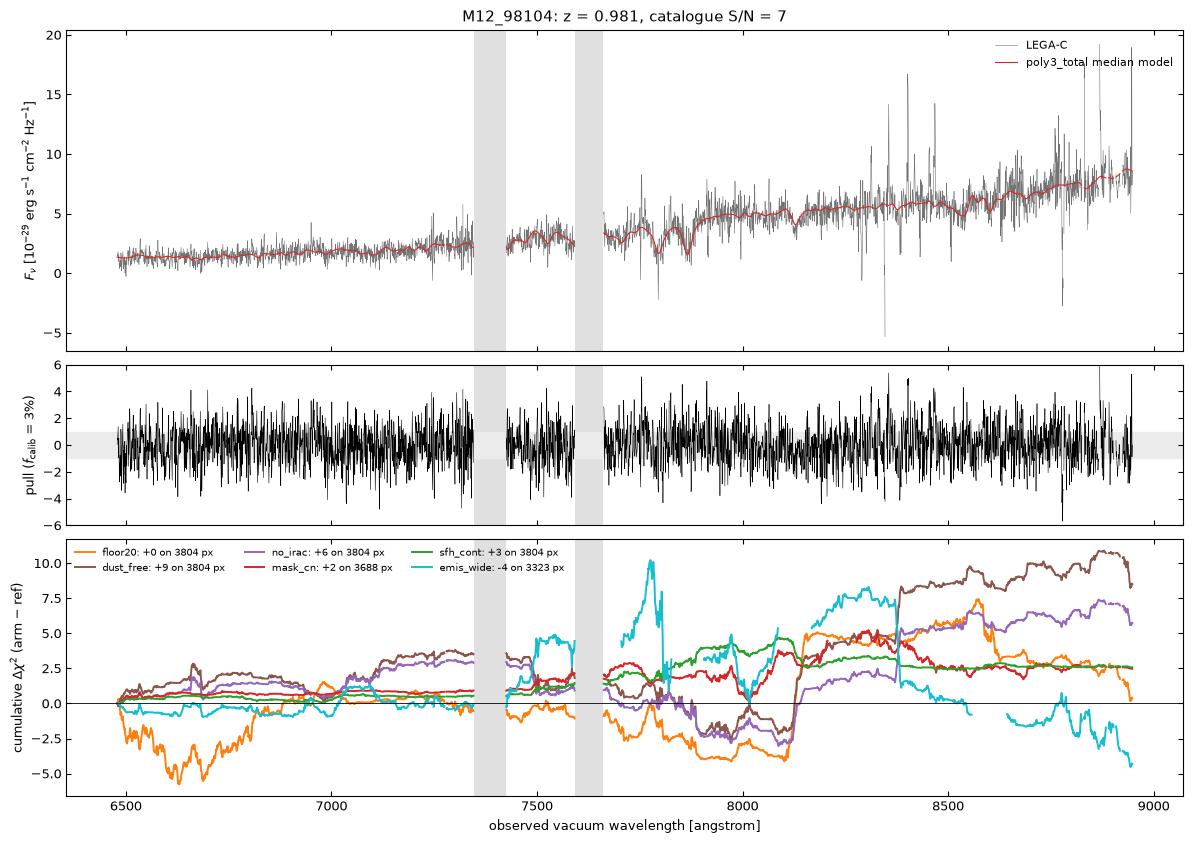

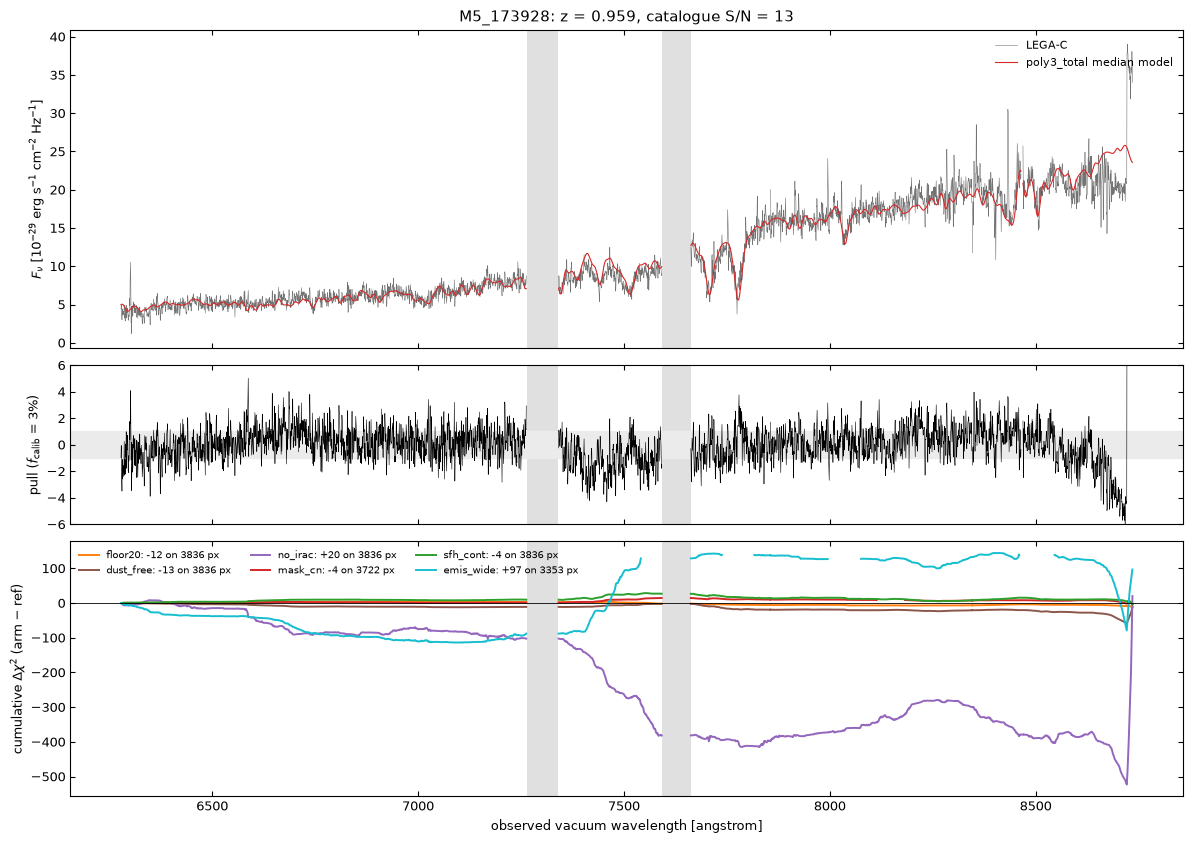

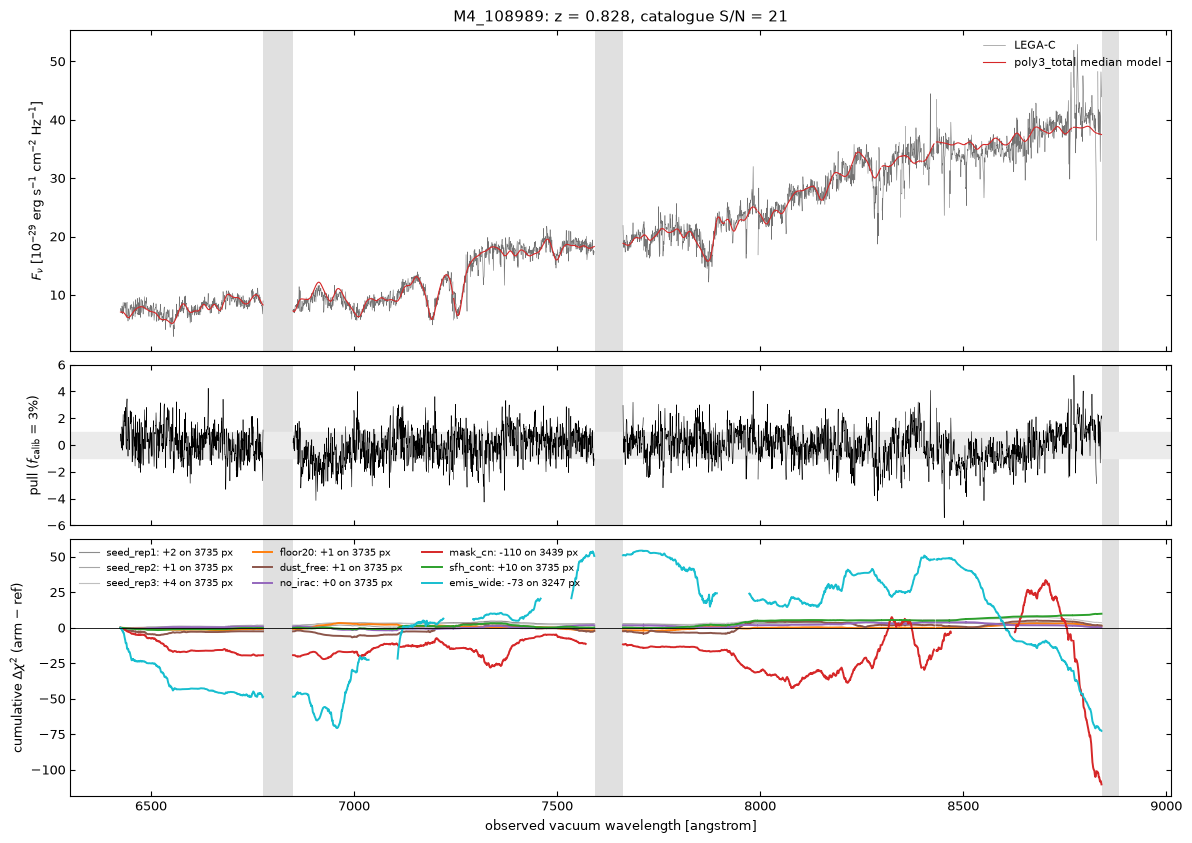

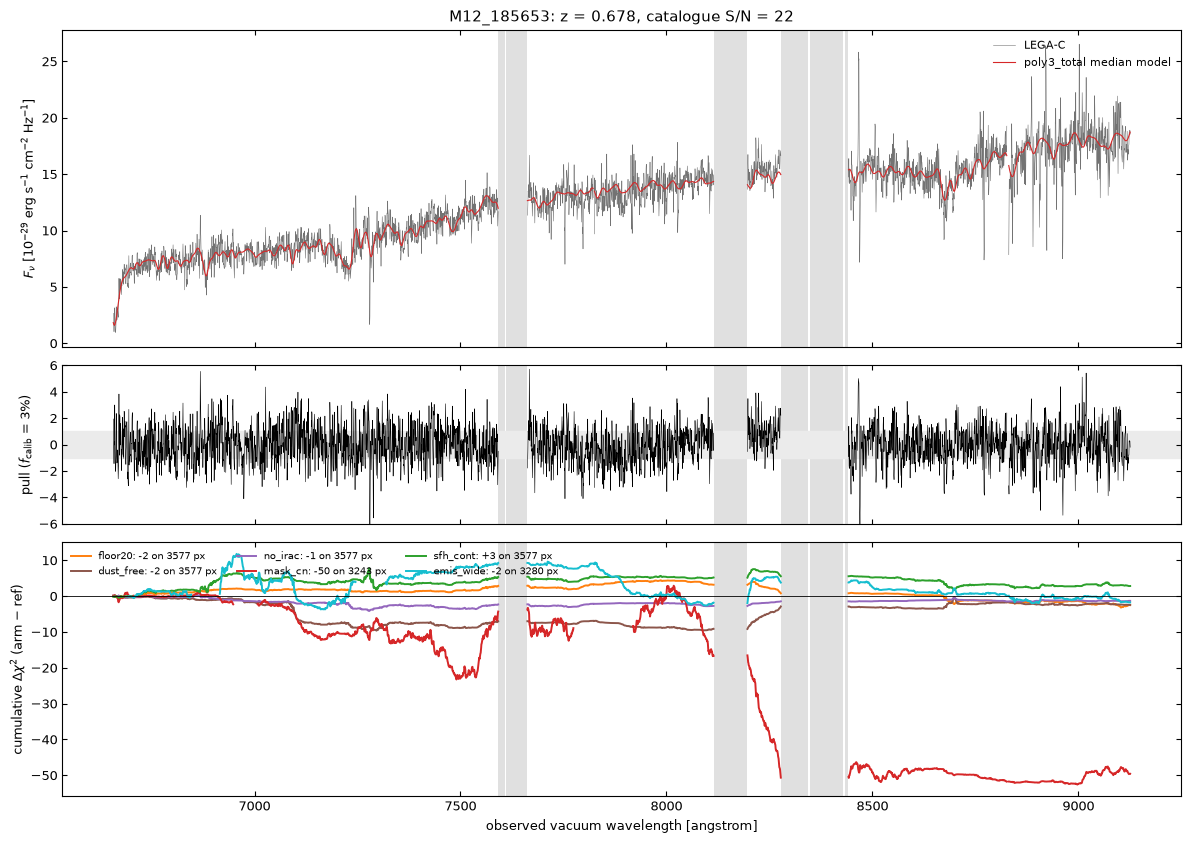

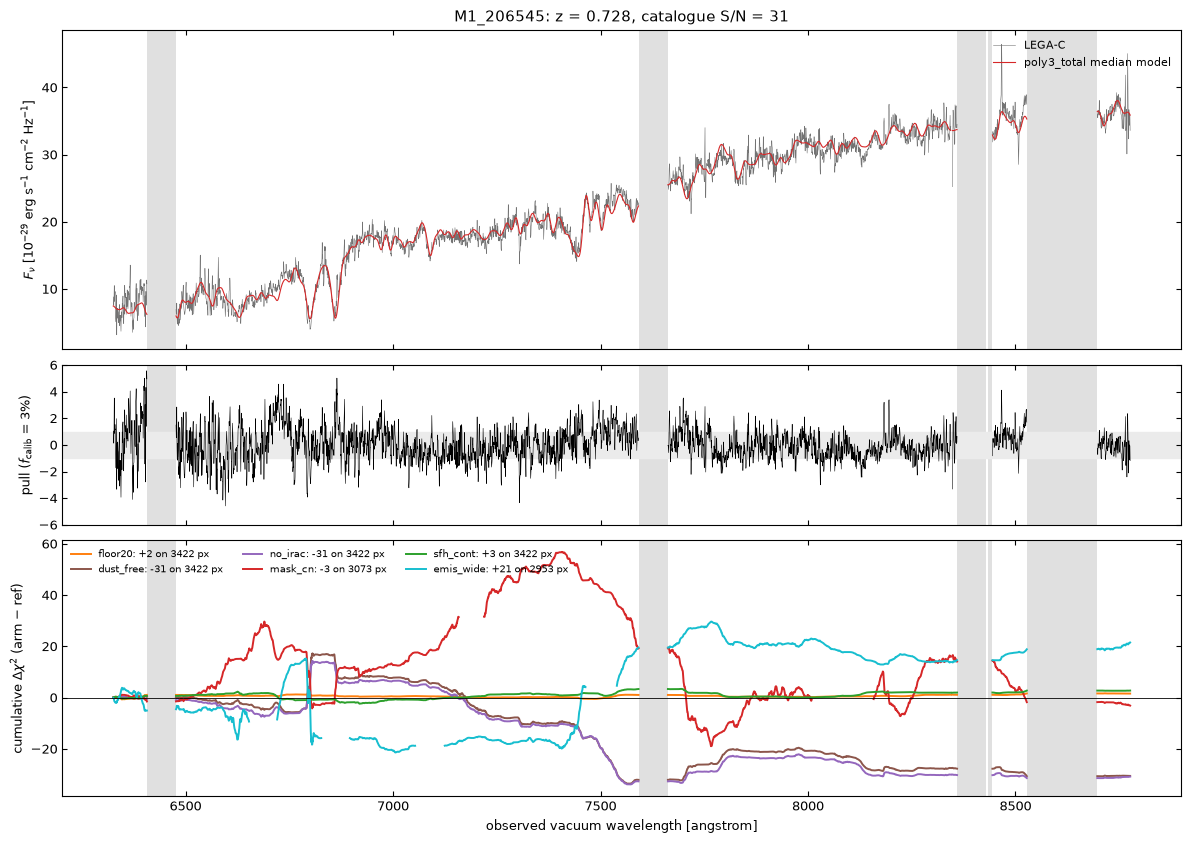

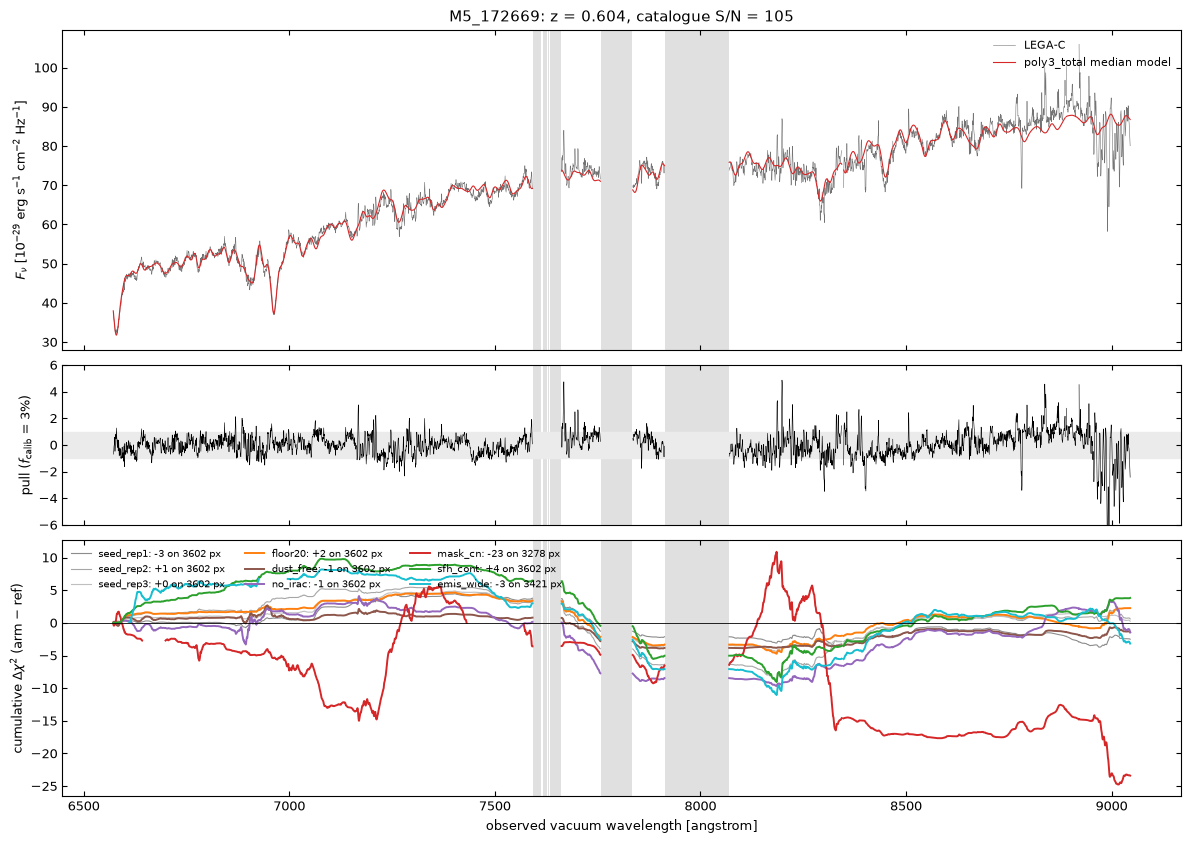

In [7]:
def _runs(wave, flag):
    edges = np.flatnonzero(np.diff(np.concatenate([[0], flag.astype(int), [0]])))
    return [(wave[s], wave[min(e, wave.size) - 1]) for s, e in zip(edges[::2], edges[1::2])]


def chi_at_f(fit, f_pct):
    s = fit["spectrum"]
    sigma = np.hypot(s["uncertainty"], (f_pct / 100.0) * np.abs(s["posterior_q50"]))
    return (s["observed"] - s["posterior_q50"]) / sigma


def spectral_figure(target):
    ref = fits[(REF_ARM, target)]
    s = ref["spectrum"]; wave = s["wavelength"]; rmask = s["mask"].astype(bool)
    excluded = (s["uncertainty"] < 1.0) & ~rmask
    fig, axes = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True, gridspec_kw={"height_ratios": [2, 1, 1.6]})
    for ax in axes:
        for lo, hi in _runs(wave, excluded):
            ax.axvspan(lo, hi, color="0.88", lw=0, zorder=0)
    scale = 1e29
    axes[0].plot(wave, np.where(rmask, s["observed"] * scale, np.nan), color="0.45", lw=0.4, label="LEGA-C")
    axes[0].plot(wave, np.where(rmask, s["posterior_q50"] * scale, np.nan), color="tab:red", lw=0.8, label=f"{REF_ARM} median model")
    axes[0].set_ylabel(r"$F_\nu$ [$10^{-29}$ erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
    axes[0].set_title(f"{target}: z = {ref['attrs']['redshift']:.3f}, catalogue S/N = {ref['attrs']['catalogue_sn']:.0f}")
    axes[0].legend(frameon=False, fontsize=8, loc="upper right")
    chi_ref = chi_at_f(ref, F_FIXED_PCT)
    axes[1].plot(wave, np.where(rmask, chi_ref, np.nan), color="k", lw=0.4)
    axes[1].axhspan(-1, 1, color="0.92", zorder=0); axes[1].set_ylim(-6, 6); axes[1].set_ylabel(r"pull ($f_{\rm calib}$ = 3%)")
    for arm in SEED_ARMS + KNOB_ARMS:
        if (arm, target) not in fits:
            continue
        fit = fits[(arm, target)]
        common = rmask & fit["spectrum"]["mask"].astype(bool)
        dchi2 = np.where(common, chi_at_f(fit, F_FIXED_PCT) ** 2 - chi_ref ** 2, 0.0)
        axes[2].plot(wave, np.where(common, np.cumsum(dchi2), np.nan), color=COLOURS[arm], lw=1.4 if arm in KNOB_ARMS else 0.8,
                     label=f"{arm}: {dchi2.sum():+.0f} on {common.sum()} px")
    axes[2].axhline(0, color="k", lw=0.6)
    axes[2].set_ylabel(r"cumulative $\Delta\chi^2$ (arm $-$ ref)"); axes[2].set_xlabel("observed vacuum wavelength [angstrom]")
    axes[2].legend(frameon=False, fontsize=7, ncol=3, loc="upper left")
    fig.tight_layout(); fig.savefig(RESULTS / f"chi2-{target}.png", dpi=130); plt.show()


for target in galaxies:
    spectral_figure(target)

## Parameter shifts

- Point: median; bar: 16-84 range; one row per arm.
- Shaded band: reference median +- the seed floor (largest repeat shift) in that parameter.

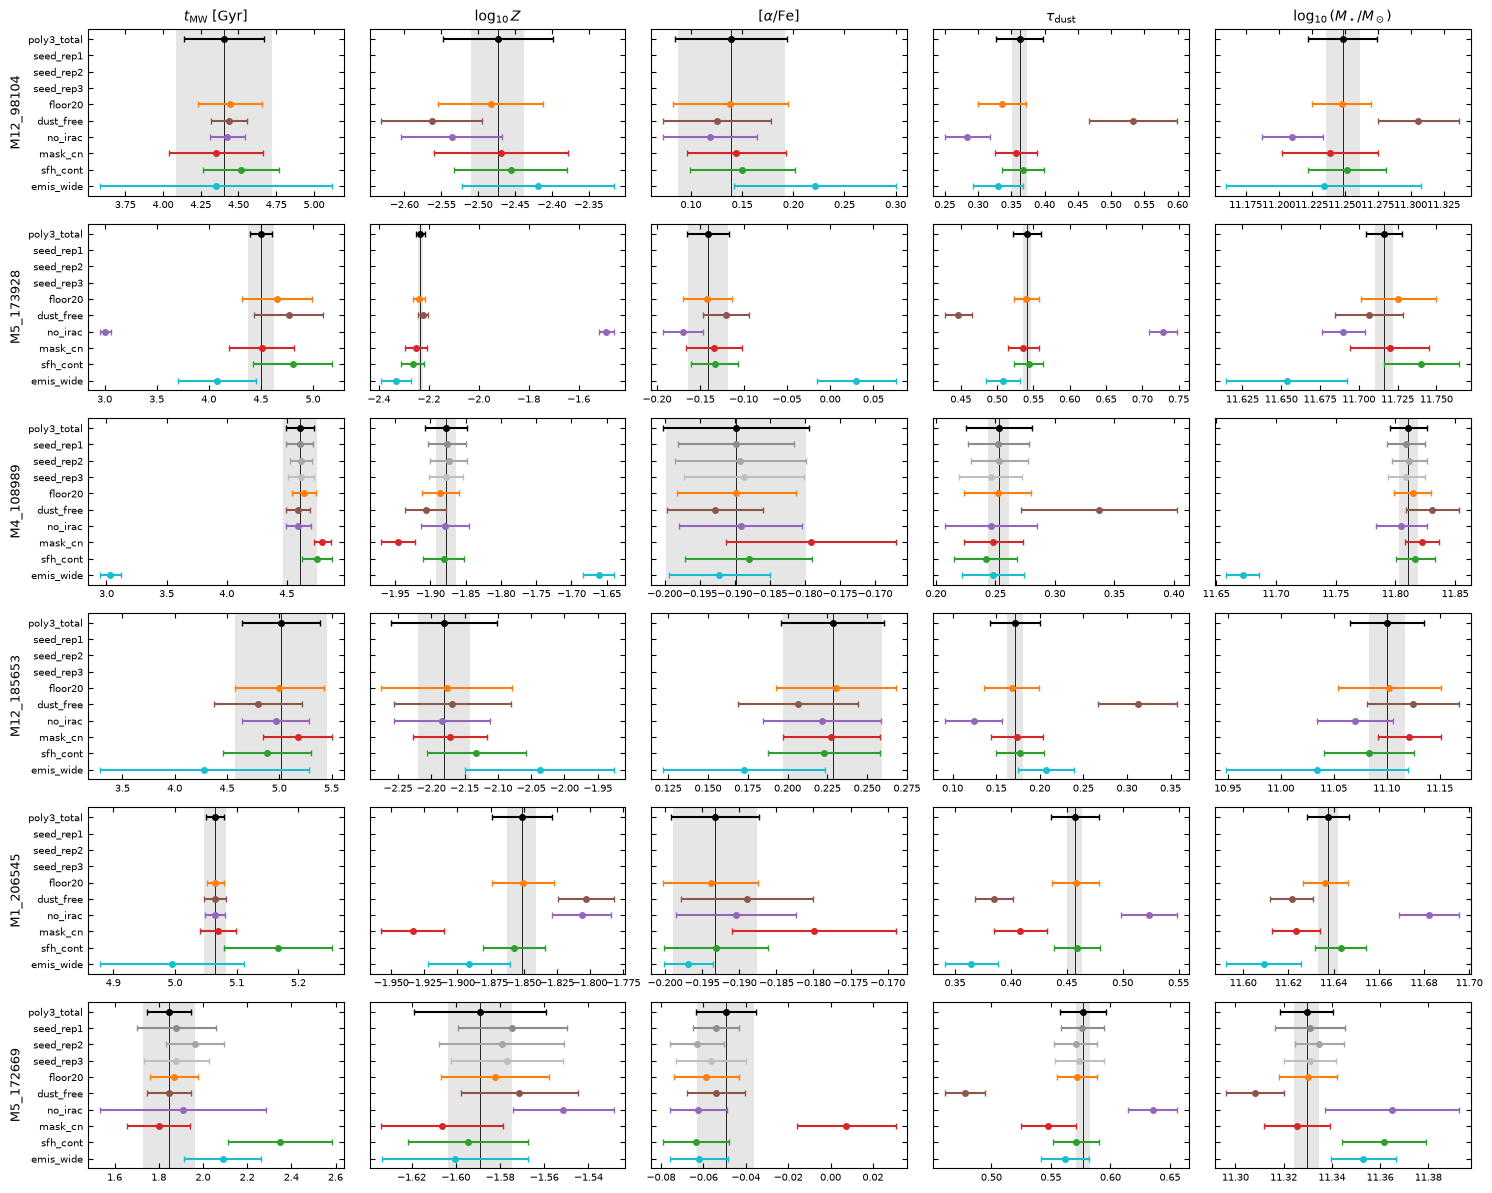

In [8]:
rows_arms = [a for a in [REF_ARM] + SEED_ARMS + KNOB_ARMS if a in arms_present]
fig, axes = plt.subplots(len(galaxies), len(PHYSICS), figsize=(3.0 * len(PHYSICS), 2.0 * len(galaxies)), squeeze=False)
for r, target in enumerate(galaxies):
    base = table.loc[(target, REF_ARM)]
    for c, name in enumerate(PHYSICS):
        ax = axes[r, c]
        band = floor.loc[name, "max |shift|"] * base[f"{name}_hw"]
        ax.axvspan(base[f"{name}_q50"] - band, base[f"{name}_q50"] + band, color="0.9", lw=0)
        ax.axvline(base[f"{name}_q50"], color="k", lw=0.6)
        for i, arm in enumerate(rows_arms):
            if (target, arm) not in table.index:
                continue
            row = table.loc[(target, arm)]
            ax.errorbar(row[f"{name}_q50"], i, xerr=row[f"{name}_hw"], fmt="o", ms=4, color=COLOURS[arm], capsize=2)
        ax.set_yticks(range(len(rows_arms))); ax.set_yticklabels(rows_arms if c == 0 else [""] * len(rows_arms), fontsize=7)
        ax.set_ylim(-0.6, len(rows_arms) - 0.4); ax.invert_yaxis(); ax.tick_params(axis="x", labelsize=7)
        if r == 0:
            ax.set_title(LABELS[name], fontsize=10)
        if c == 0:
            ax.set_ylabel(target, fontsize=9)
fig.tight_layout(); fig.savefig(RESULTS / "parameters-shift.png", dpi=130); plt.show()

## Star-formation and age histories

- Left: median SFR at the lookback nodes, normalised to unit formed mass.
- Right: median mass fraction formed younger than each lookback time.

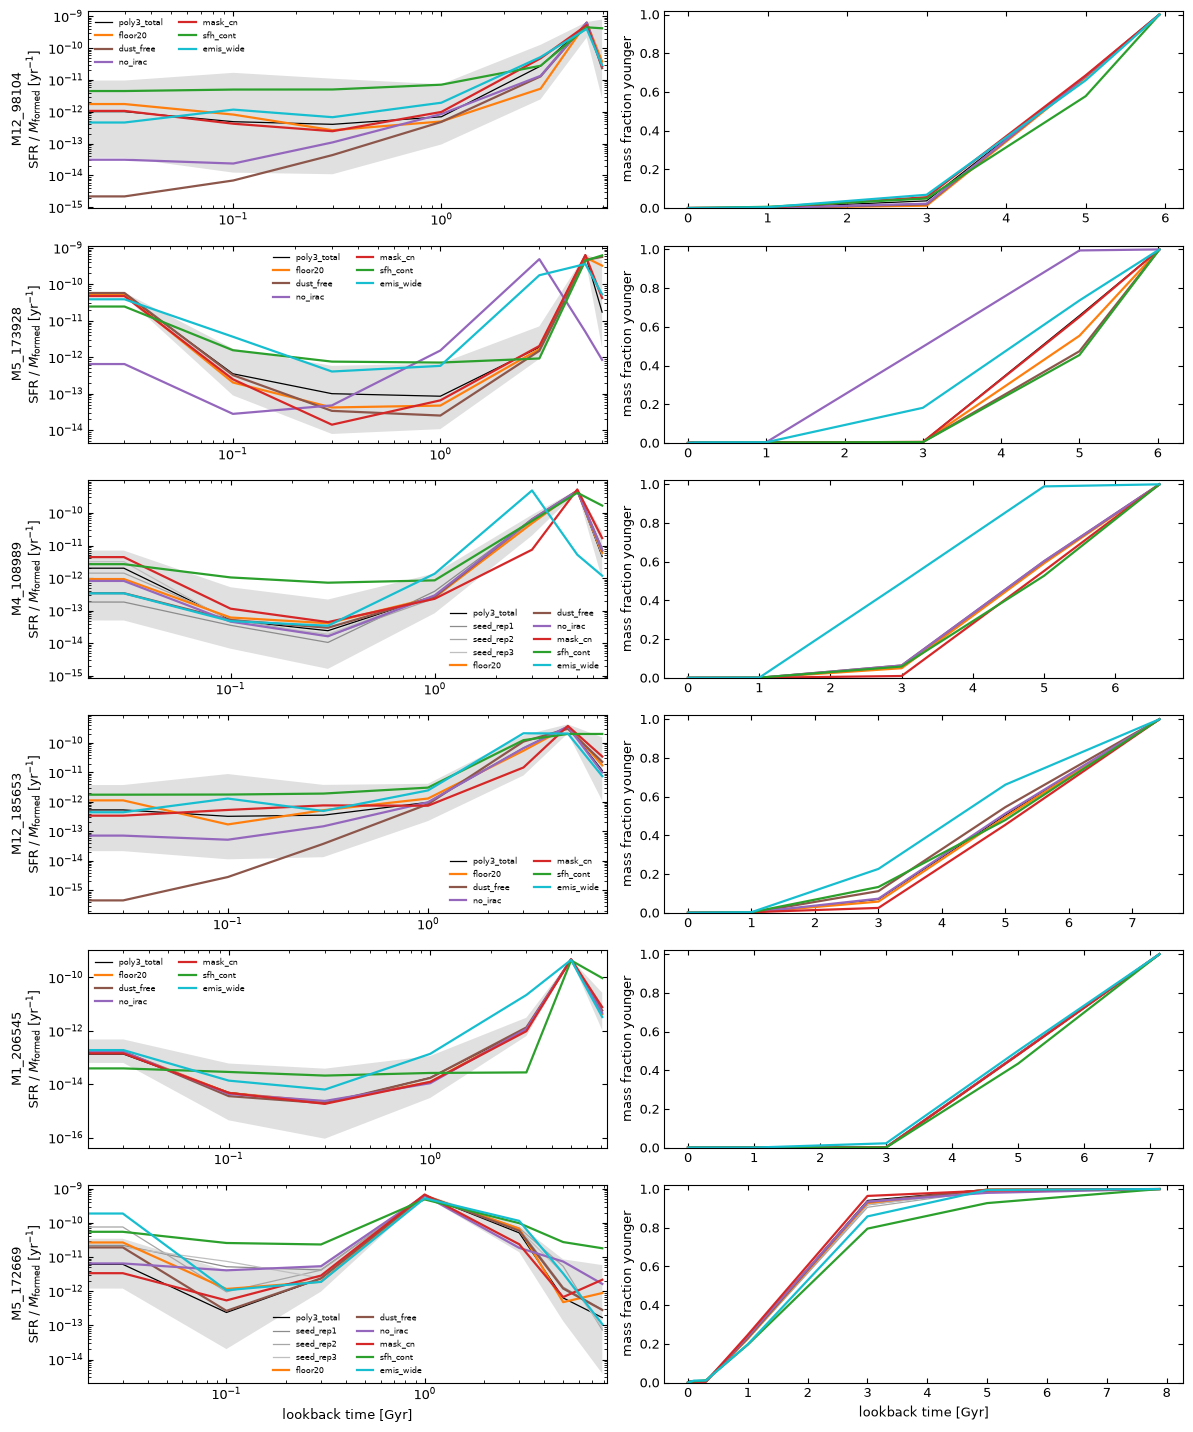

In [9]:
fig, axes = plt.subplots(len(galaxies), 2, figsize=(12, 2.4 * len(galaxies)), squeeze=False)
for r, target in enumerate(galaxies):
    for arm in rows_arms:
        if (arm, target) not in fits:
            continue
        sfh = fits[(arm, target)]["sfh"]; lb = sfh["lookback_time_gyr"]
        kw = dict(color=COLOURS[arm], lw=1.6 if arm in KNOB_ARMS else 0.9, label=arm)
        axes[r, 0].plot(lb, sfh["normalized_sfr_q50"], **kw)
        if arm == REF_ARM:
            axes[r, 0].fill_between(lb, sfh["normalized_sfr_q16"], sfh["normalized_sfr_q84"], color="0.8", alpha=0.6, lw=0)
        younger = np.concatenate([[0.0], np.cumsum(sfh["mass_fraction_q50"])])
        axes[r, 1].plot(lb, younger / younger[-1], **kw)
    axes[r, 0].set(xscale="log", yscale="log", ylabel=f"{target}\n" + r"SFR / $M_{\rm formed}$ [yr$^{-1}$]")
    axes[r, 0].set_xlim(0.02, lb[-1] * 1.05)
    axes[r, 1].set(ylabel="mass fraction younger", ylim=(0, 1.02))
    axes[r, 0].legend(frameon=False, fontsize=6, ncol=2)
for ax in axes[-1]:
    ax.set_xlabel("lookback time [Gyr]")
fig.tight_layout(); fig.savefig(RESULTS / "sfh-histories.png", dpi=130); plt.show()

## SFH under the two priors, per galaxy

- Uniform(-3, 3) on logsfr_ratios (poly3_total) against StudentT(0, 0.3, df 2) (sfh_cont, the production default since 2026-09-06).
- Bands: 16-84 percent over posterior draws. Right: mass fraction formed younger than each lookback time.
- Table: t_MW, t20, t50, t80 under each prior; shift in units of the uniform-prior half width.

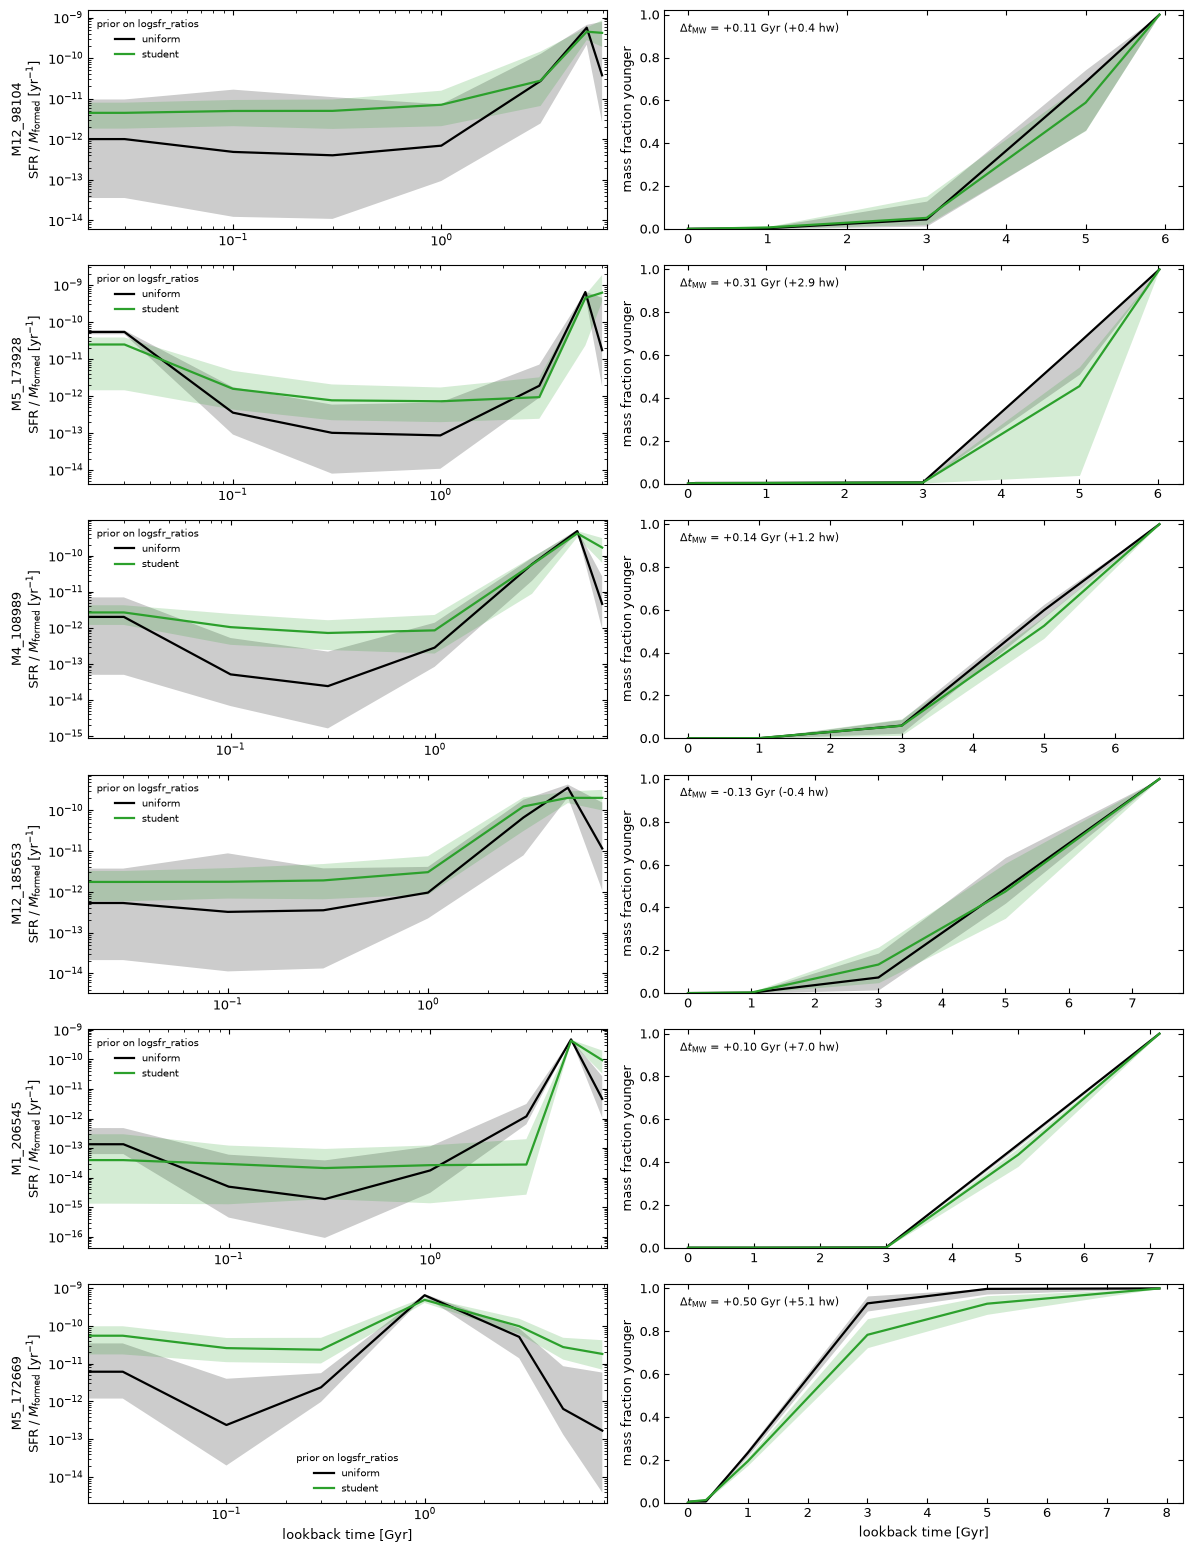

,age_uniform,t50_uniform,age_student,t50_student,age_shift_hw,t20_shift_hw,t50_shift_hw,t80_shift_hw
target,,,,,,,,
M12_98104,4.40,4.44,4.52,4.68,0.42,0.25,0.57,0.73
M5_173928,4.50,4.51,4.80,5.08,2.90,3.36,2.51,2.35
M4_108989,4.61,4.64,4.75,4.89,1.22,0.75,2.31,2.06
M12_185653,5.02,5.06,4.89,5.12,-0.35,-0.66,0.14,0.10
M1_206545,5.06,5.07,5.17,5.25,7.00,7.34,7.12,7.12
M5_172669,1.85,1.77,2.35,2.05,5.05,2.91,4.11,6.84


In [10]:
def younger_draws(sfh):
    fr = sfh["mass_fraction_draws"]
    return np.concatenate([np.zeros((len(fr), 1)), np.cumsum(fr, axis=1)], axis=1)

PRIOR_ARMS = {REF_ARM: ("uniform", "k"), "sfh_cont": ("student", COLOURS["sfh_cont"])}
prior_rows = []
pairs = [t for t in galaxies if ("sfh_cont", t) in fits]
fig, axes = plt.subplots(len(pairs), 2, figsize=(12, 2.6 * len(pairs)), squeeze=False)
for r, target in enumerate(pairs):
    row = dict(target=target)
    for arm, (prior, colour) in PRIOR_ARMS.items():
        sfh = fits[(arm, target)]["sfh"]; lb = sfh["lookback_time_gyr"]
        axes[r, 0].plot(lb, sfh["normalized_sfr_q50"], color=colour, lw=1.6, label=prior)
        axes[r, 0].fill_between(lb, sfh["normalized_sfr_q16"], sfh["normalized_sfr_q84"], color=colour, alpha=0.2, lw=0)
        yd = younger_draws(sfh); q16, q50, q84 = np.percentile(yd, [16, 50, 84], axis=0)
        axes[r, 1].plot(lb, q50, color=colour, lw=1.6, label=prior)
        axes[r, 1].fill_between(lb, q16, q84, color=colour, alpha=0.2, lw=0)
        t20, t50, t80 = formation_times(lb, sfh["mass_fraction_draws"])
        for name, draws in [("age", sfh["mass_weighted_age_gyr"]), ("t20", t20), ("t50", t50), ("t80", t80)]:
            lo, mid, hi = np.percentile(draws, [16, 50, 84])
            row[f"{name}_{prior}"], row[f"{name}_{prior}_hw"] = mid, 0.5 * (hi - lo)
    for name in ("age", "t20", "t50", "t80"):
        row[f"{name}_shift_hw"] = (row[f"{name}_student"] - row[f"{name}_uniform"]) / row[f"{name}_uniform_hw"]
    prior_rows.append(row)
    axes[r, 0].set(xscale="log", yscale="log", ylabel=f"{target}\n" + r"SFR / $M_{\rm formed}$ [yr$^{-1}$]")
    axes[r, 0].set_xlim(0.02, lb[-1] * 1.05)
    axes[r, 1].set(ylabel="mass fraction younger", ylim=(0, 1.02))
    axes[r, 1].text(0.03, 0.9, rf"$\Delta t_{{\rm MW}}$ = {row['age_student'] - row['age_uniform']:+.2f} Gyr ({row['age_shift_hw']:+.1f} hw)",
                    transform=axes[r, 1].transAxes, fontsize=8)
    axes[r, 0].legend(frameon=False, fontsize=7, title="prior on logsfr_ratios", title_fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("lookback time [Gyr]")
fig.tight_layout(); fig.savefig(RESULTS / "sfh-continuity.png", dpi=130); plt.show()
sfh_prior_table = pd.DataFrame(prior_rows).set_index("target")
sfh_prior_table.to_csv(RESULTS / "sfh-prior-compare.csv")
sfh_prior_table[[c for c in sfh_prior_table if c.startswith(("age", "t50")) and "hw" not in c or c.endswith("shift_hw")]].round(2)

## Corner plots

- Weighted dead points of every arm; contour at the 1-sigma level of the 2-d mass.
- Mass-weighted age computed per sample with the notebook's trapezoid convention.

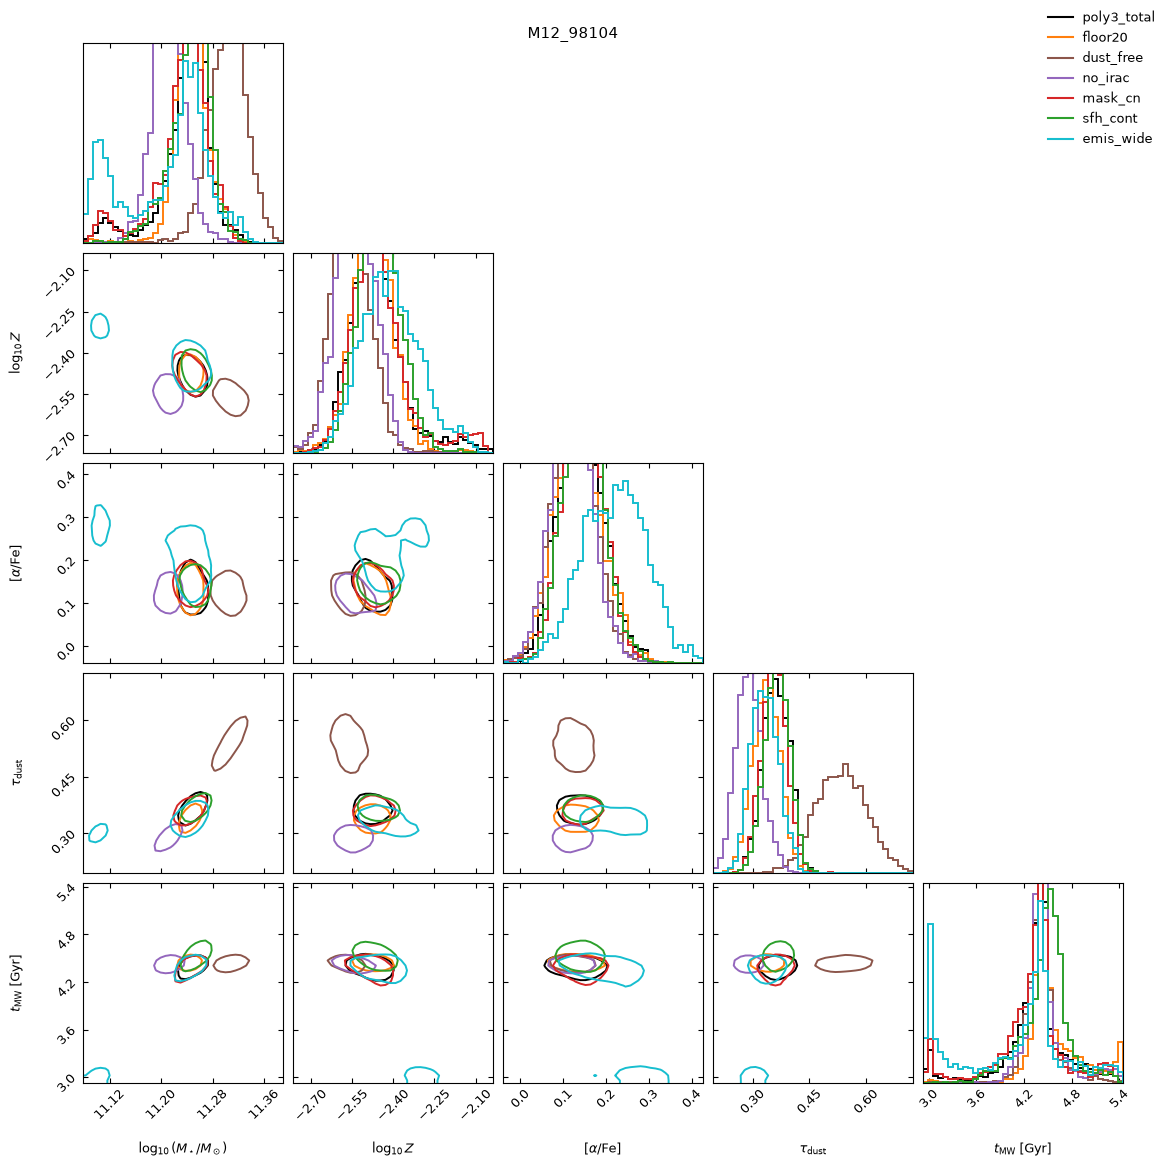

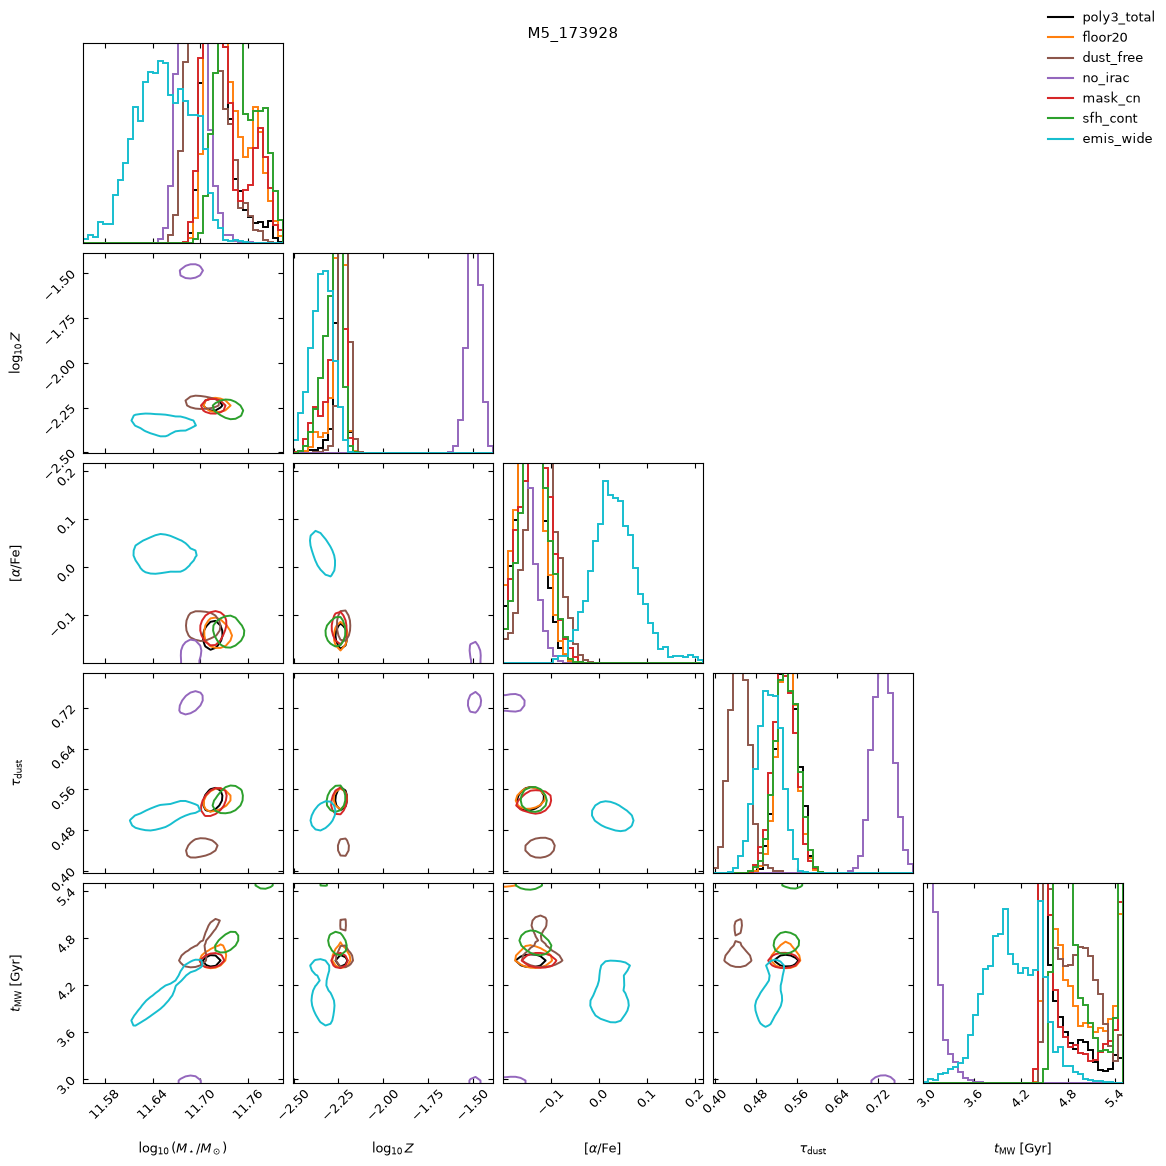

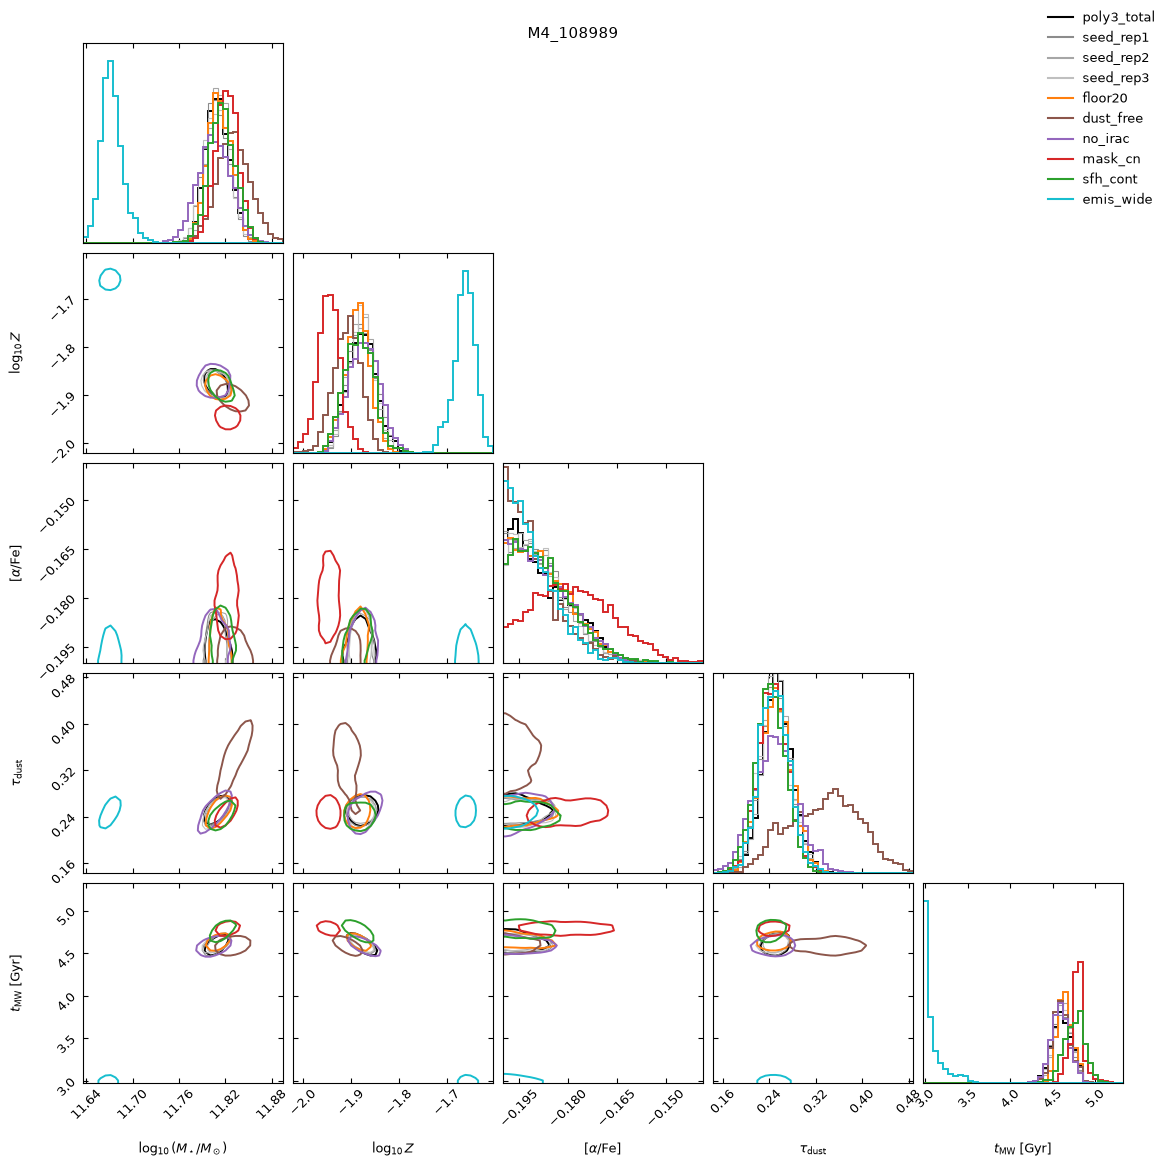

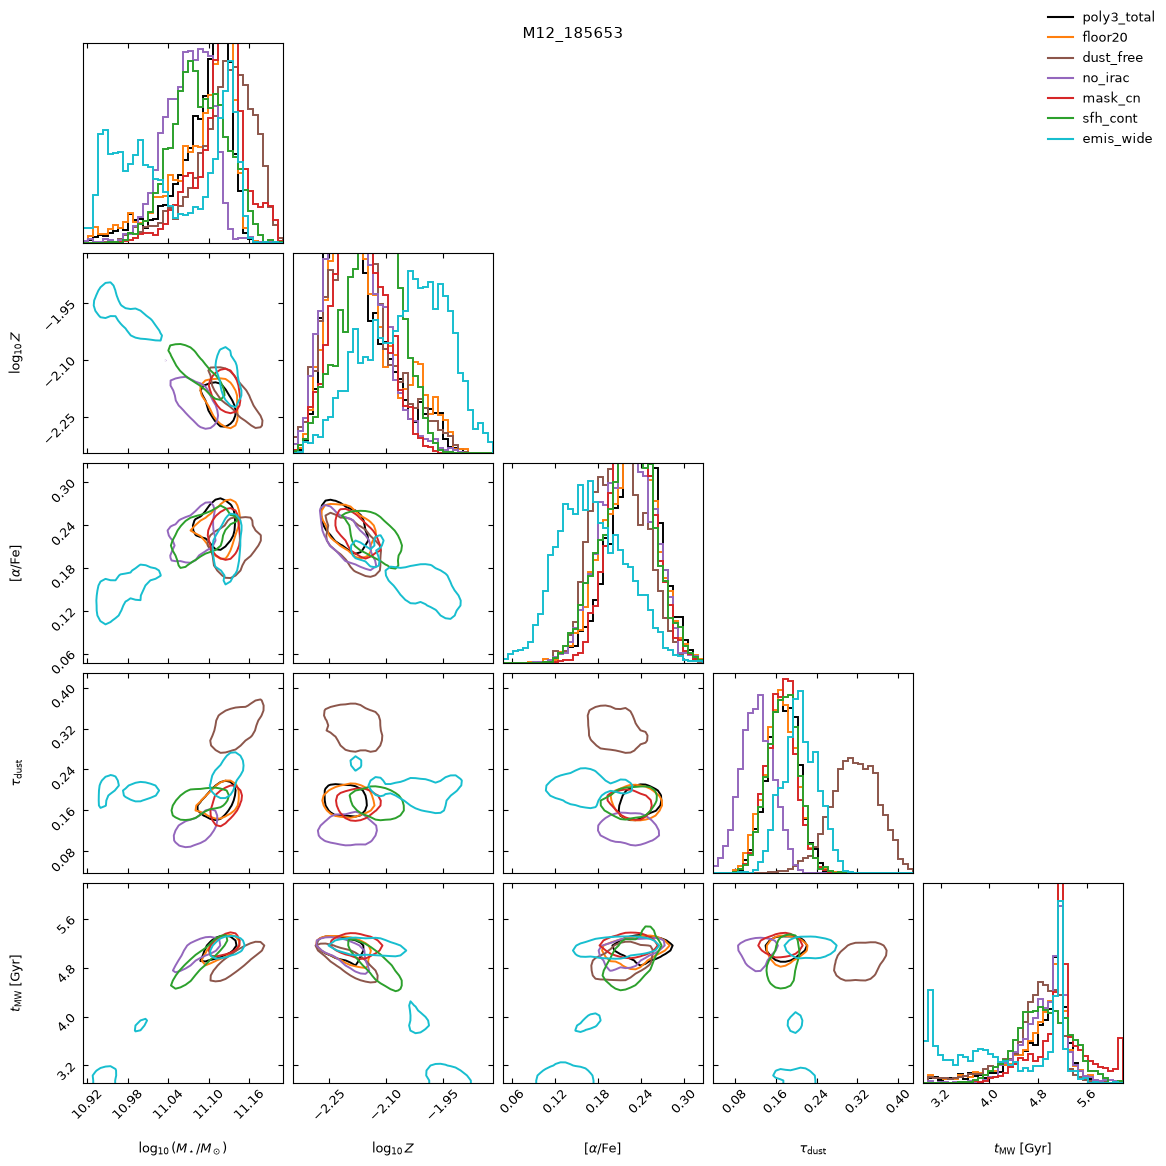

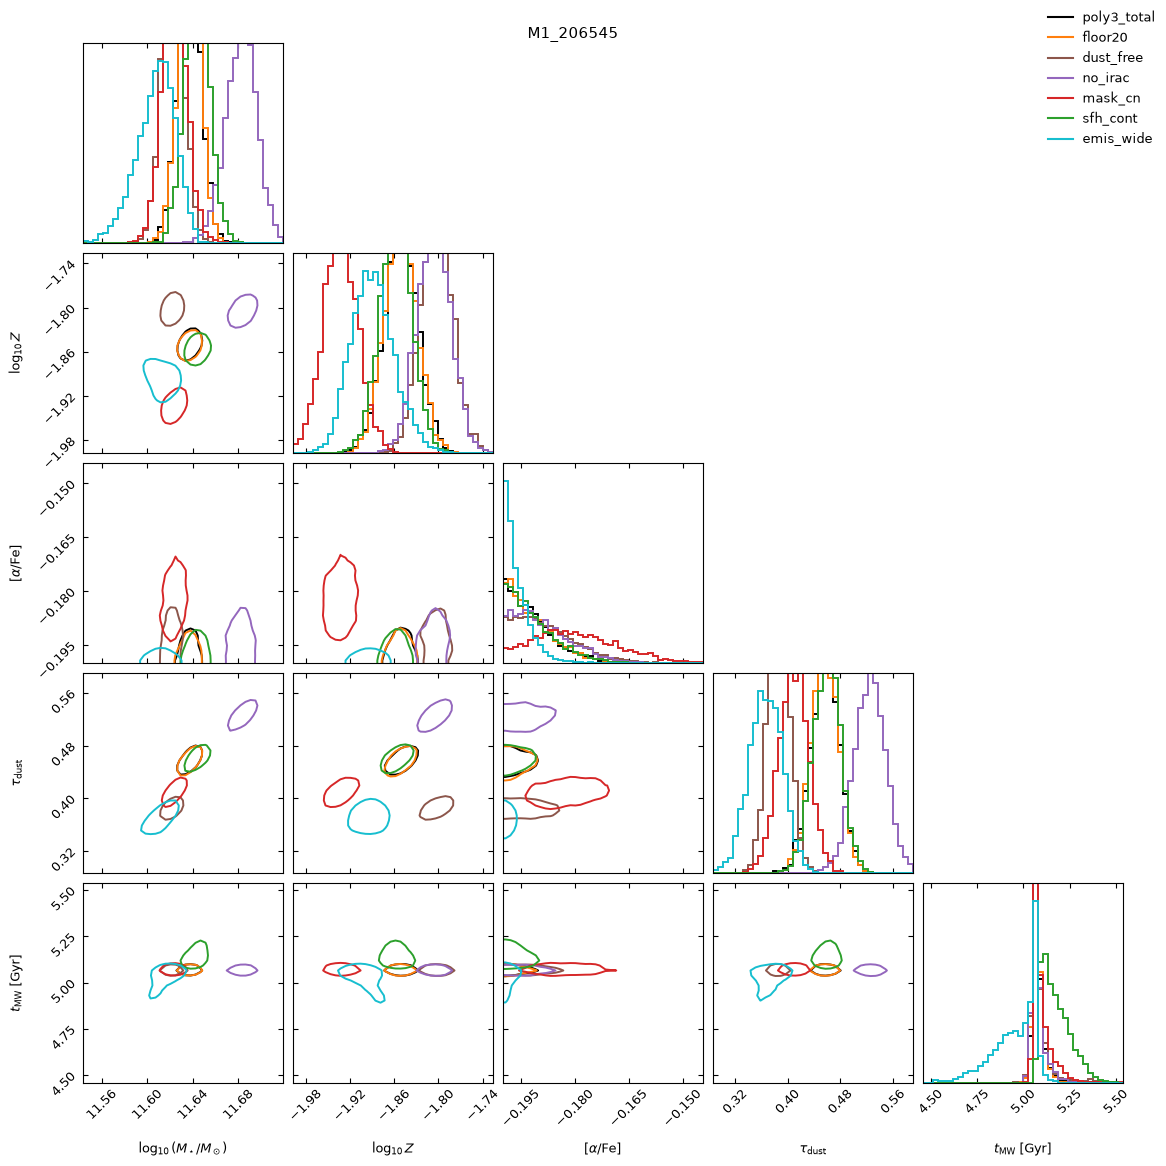

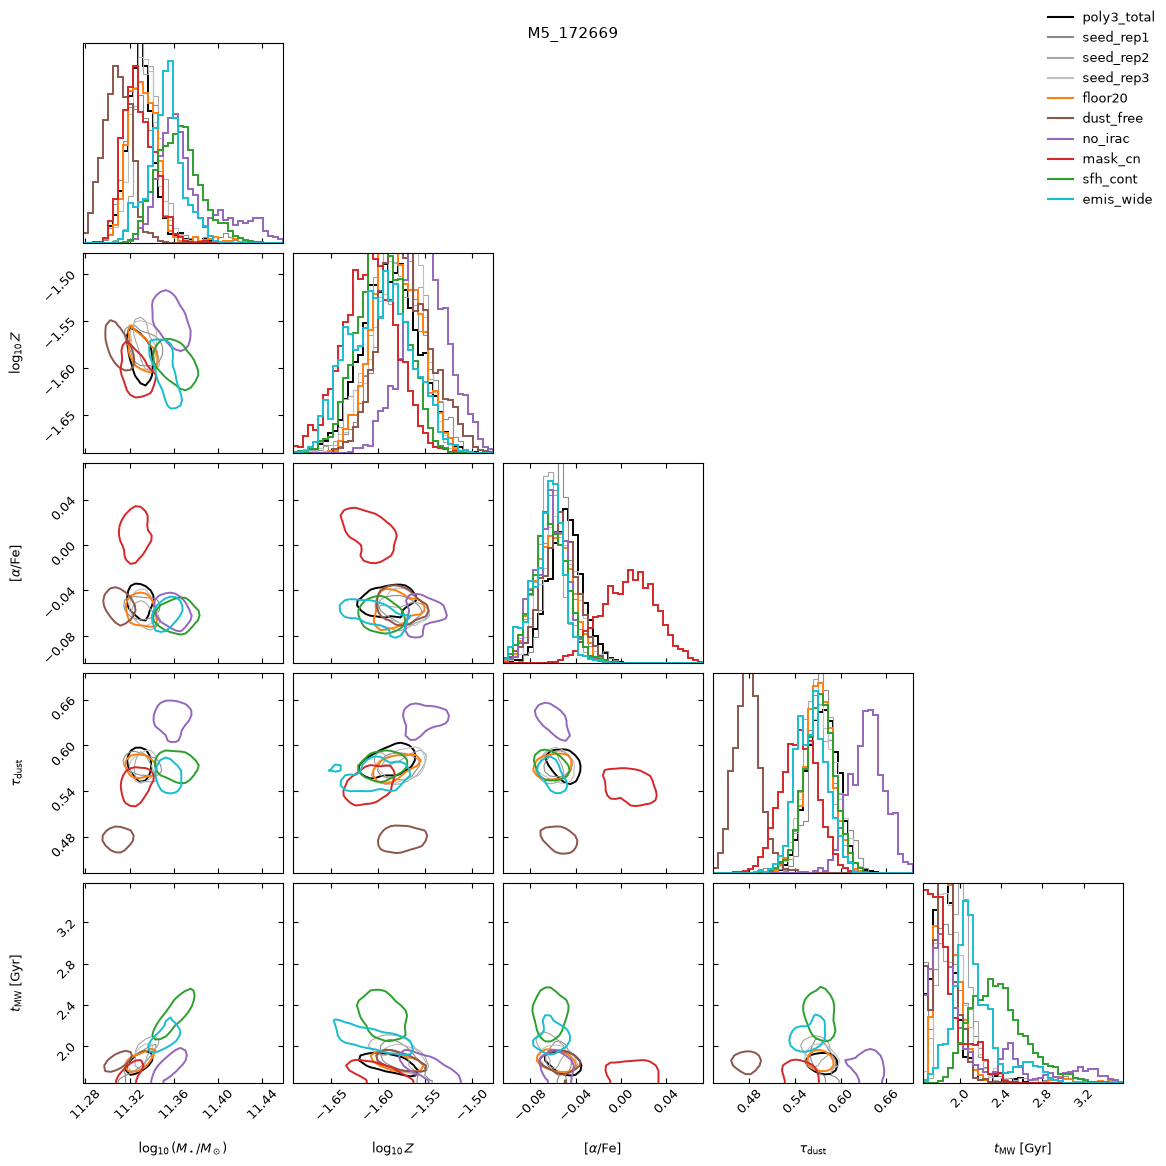

In [11]:
CORNER_LABELS = [LABELS[p] for p in ["logmass", "Z", "afe", "tau_dust", "age"]]


def corner_data(g):
    return np.column_stack([g.samples["logmass"], g.samples["Z"], g.samples["afe"], g.samples["diffuse_tau_kc"], mw_age_samples(g)])


for target in galaxies:
    present = [a for a in rows_arms if (a, target) in fits]
    data = {a: (corner_data(fits[(a, target)]["galaxy"]), pgd.posterior_weights(fits[(a, target)]["galaxy"])) for a in present}
    lo = np.min([[pgd.weighted_quantile(x[:, k], w, 0.002) for k in range(5)] for x, w in data.values()], axis=0)
    hi = np.max([[pgd.weighted_quantile(x[:, k], w, 0.998) for k in range(5)] for x, w in data.values()], axis=0)
    rng_ = [(a, b) if b > a else (a - 1e-3, a + 1e-3) for a, b in zip(lo, hi)]
    fig = None
    for a in present:
        x, w = data[a]
        fig = corner.corner(x, weights=w, labels=CORNER_LABELS, range=rng_, color=COLOURS[a], fig=fig, bins=40, smooth=1.0,
                            plot_datapoints=False, plot_density=False, fill_contours=False, levels=[1 - np.exp(-0.5)],
                            hist_kwargs=dict(density=True, lw=1.4 if a in KNOB_ARMS or a == REF_ARM else 0.8),
                            contour_kwargs=dict(linewidths=1.4 if a in KNOB_ARMS or a == REF_ARM else 0.8))
    fig.legend(handles=[plt.Line2D([], [], color=COLOURS[a], label=a) for a in present], loc="upper right", frameon=False, fontsize=9)
    fig.suptitle(target, y=0.98)
    fig.savefig(RESULTS / f"corner-{target}.png", dpi=110); plt.show()

## Lick indices per arm

- Every fit rebuilt on CPU with `StellarIndices` riding along; 200 weighted posterior draws.
- Residual = (model q50 - catalogue) / sqrt(catalogue err^2 + posterior half-width^2).
- `lnL rebuilt/stored - 1` checks the rebuild reproduces each arm's likelihood.

In [12]:
INDEX_MAP = {"CN1": "LICK_CN1", "CN2": "LICK_CN2", "Ca4227": "LICK_CA4227", "G4300": "LICK_G4300", "Fe4383": "LICK_FE4383",
             "Ca4455": "LICK_CA4455", "Fe4531": "LICK_FE4531", "C4668": "LICK_C4668", "Hbeta": "LICK_HB", "HdA": "LICK_HD_A",
             "HgA": "LICK_HG_A", "HdF": "LICK_HD_F", "HgF": "LICK_HG_F", "Dn4000": "LICK_D4000_N"}
KEY_INDICES = ["HdA", "HdF", "Fe4383", "Dn4000", "Hbeta", "CN1", "C4668"]
cat = Table.read(PROJECT_ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz").to_pandas()
cat["SPECT_ID"] = cat["SPECT_ID"].astype(str).str.strip()
cat = cat.set_index("SPECT_ID").loc[galaxies]
N_DRAWS = 200
rng = np.random.default_rng(20260906)
ssp = pgd.load_ssp()
lick_rows, rebuild_rows = [], []
t0 = time.time()
for (arm, target), fit in sorted(fits.items()):
    if arm in (MOCK_REF, MOCK_ARM):
        continue
    g = fit["galaxy"]
    indices_obs = StellarIndices(definitions=LEGAC_DR2_STELLAR_INDEX_DEFINITIONS, resolution=g.spec["resolution"], smoothtype=g.spec["smoothtype"],
                                 res_convention=pgd.RES_CONVENTION, sigma_losvd=g.sigma_star_kms, name="stellar_indices")
    model, likelihood, _ = pgd.rebuild_model(g, ssp, extra_observations=(indices_obs,))
    k = pgd.max_likelihood_index(g)
    rebuild_rows.append({"arm": arm, "target": target, "lnL rebuilt/stored - 1": pgd.likelihood_terms(model, likelihood, pgd.theta_at(g, k))["lnl"] / g.log_likelihoods[k] - 1})
    w = pgd.posterior_weights(g)
    draws = rng.choice(len(w), size=N_DRAWS, replace=True, p=w)
    predict = jax.jit(lambda th: model.predict(th)["stellar_indices"])
    vals = np.array([np.asarray(predict(pgd.theta_at(g, j))) for j in draws])
    q16, q50, q84 = np.percentile(vals, [16, 50, 84], axis=0)
    for i, name in enumerate(indices_obs.index_names):
        obs, err = float(cat.loc[target, INDEX_MAP[name]]), float(cat.loc[target, INDEX_MAP[name] + "_err"])
        if not np.isfinite(err) or err <= 0:
            obs = np.nan
        lick_rows.append({"arm": arm, "target": target, "index": name, "catalogue": obs, "cat err": err, "model q50": q50[i],
                          "model hw": 0.5 * (q84[i] - q16[i]), "resid": (q50[i] - obs) / np.hypot(err, 0.5 * (q84[i] - q16[i]))})
print(f"{len(rebuild_rows)} fits rebuilt in {time.time() - t0:.0f} s")
lick = pd.DataFrame(lick_rows)
rebuild = pd.DataFrame(rebuild_rows).set_index(["target", "arm"]).sort_index()
assert rebuild["lnL rebuilt/stored - 1"].abs().max() < 1e-2, rebuild
rebuild.unstack("arm").round(5)

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


/Users/liuhao/Downloads/Astro project/ceridwen/ceridwen/model/model.py:241: UserWarning: Spectrum 'spectrum': the SSP library resolution meets or exceeds the target resolution on 4% of pixels over [5248, 5945] AA (km/s); those pixels stay at LIBRARY resolution (no deconvolution is attempted).  The model cannot be as sharp as the data there — use a higher-resolution SSP grid.
  obs.setup_for_model(


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


...

Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


Using only diffuse dust attenuation.
Initializing DiffuseDust model...
Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


48 fits rebuilt in 51 s


lnL rebuilt/stored - 1                                                                                     
arm                     dust_free emis_wide floor20 mask_cn no_irac poly3_total seed_rep1 seed_rep2 seed_rep3 sfh_cont
target                                                                                                                
M12_185653                   -0.0      -0.0    -0.0    -0.0    -0.0        -0.0       NaN       NaN       NaN     -0.0
M12_98104                    -0.0      -0.0    -0.0    -0.0    -0.0        -0.0       NaN       NaN       NaN     -0.0
M1_206545                    -0.0      -0.0    -0.0    -0.0    -0.0        -0.0       NaN       NaN       NaN     -0.0
M4_108989                    -0.0      -0.0    -0.0    -0.0    -0.0        -0.0      -0.0      -0.0      -0.0     -0.0
M5_172669                     0.0       0.0     0.0     0.0     0.0         0.0       0.0       0.0       0.0      0.0
M5_173928                    -0.0      -0.0    -0.0    -0.0    -0.0         0.0       NaN       NaN       NaN      0.0

In [13]:
# mean |residual| over the key indices, per arm and galaxy
key = lick[lick["index"].isin(KEY_INDICES)]
lick_abs = key.groupby(["arm", "target"])["resid"].apply(lambda s: s.abs().mean()).unstack("target")
lick_abs = lick_abs.reindex([a for a in rows_arms if a in lick_abs.index])
lick_abs["mean"] = lick_abs[galaxies].mean(axis=1)
# change against the reference on the same galaxies only; negative = closer to the catalogue
lick_abs["vs ref"] = (lick_abs[galaxies] - lick_abs.loc[REF_ARM, galaxies]).mean(axis=1)
lick_abs.to_csv(RESULTS / "lick-by-arm.csv")
lick_abs

target,M12_185653,M12_98104,M1_206545,M4_108989,M5_172669,M5_173928,mean,vs ref
arm,,,,,,,,
poly3_total,2.488,1.014,2.218,3.417,1.900,2.825,2.310,0.000
seed_rep1,NaN,NaN,NaN,3.448,1.979,NaN,2.714,0.055
seed_rep2,NaN,NaN,NaN,3.429,1.909,NaN,2.669,0.011
seed_rep3,NaN,NaN,NaN,3.425,1.987,NaN,2.706,0.047
floor20,2.452,1.214,2.218,3.445,1.923,2.759,2.335,0.025
dust_free,2.403,1.280,2.211,3.601,1.881,2.756,2.355,0.045
no_irac,2.501,1.226,2.168,3.424,1.987,1.550,2.143,-0.168
mask_cn,2.539,1.003,2.495,3.725,2.228,2.807,2.466,0.156
sfh_cont,2.352,0.955,2.226,3.464,1.829,2.728,2.259,-0.051


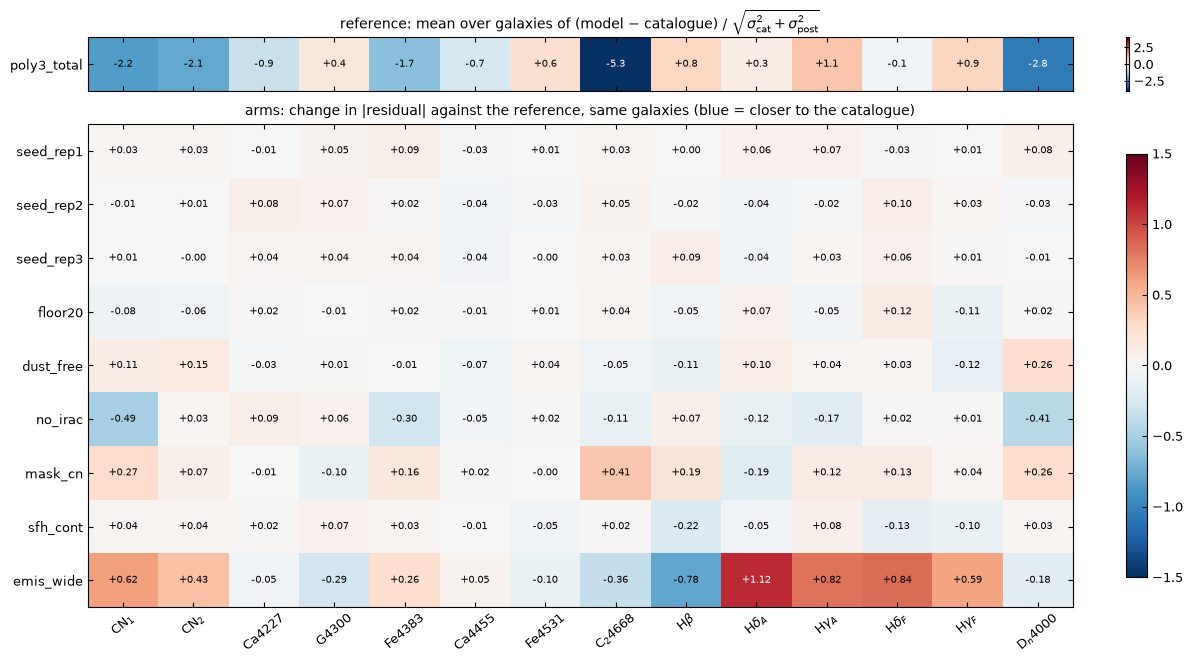

In [14]:
INDEX_LABELS = {"CN1": r"CN$_1$", "CN2": r"CN$_2$", "Ca4227": "Ca4227", "G4300": "G4300", "Fe4383": "Fe4383", "Ca4455": "Ca4455",
                "Fe4531": "Fe4531", "C4668": r"C$_2$4668", "Hbeta": r"H$\beta$", "HdA": r"H$\delta_A$", "HgA": r"H$\gamma_A$",
                "HdF": r"H$\delta_F$", "HgF": r"H$\gamma_F$", "Dn4000": r"D$_n$4000"}
resid = lick.set_index(["arm", "target", "index"])["resid"]
ref_resid = resid.xs(REF_ARM, level="arm")
# top row: reference signed residual, mean over galaxies; below: change in |residual| against the reference on the same galaxies
signed_ref = ref_resid.groupby("index").mean().reindex(list(INDEX_MAP))
arm_rows = [a for a in rows_arms if a != REF_ARM and a in lick["arm"].unique()]
delta_abs = pd.DataFrame({a: (resid.xs(a, level="arm").abs() - ref_resid.abs().reindex(resid.xs(a, level="arm").index)).groupby("index").mean()
                          for a in arm_rows}).T.reindex(columns=list(INDEX_MAP))
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 0.45 * (len(arm_rows) + 1) + 2.2), gridspec_kw={"height_ratios": [1, max(len(arm_rows), 1)]}, sharex=True)
im0 = ax0.imshow(signed_ref.to_numpy()[None, :], aspect="auto", cmap="RdBu_r", vmin=-4, vmax=4)
ax0.set_yticks([0]); ax0.set_yticklabels([REF_ARM])
for j, v in enumerate(signed_ref.to_numpy()):
    ax0.text(j, 0, f"{v:+.1f}", ha="center", va="center", fontsize=7, color="k" if abs(v) < 2.5 else "w")
ax0.set_title(r"reference: mean over galaxies of (model $-$ catalogue) / $\sqrt{\sigma_{\rm cat}^2+\sigma_{\rm post}^2}$", fontsize=10)
im1 = ax1.imshow(delta_abs.to_numpy(), aspect="auto", cmap="RdBu_r", vmin=-1.5, vmax=1.5)
ax1.set_yticks(range(len(arm_rows))); ax1.set_yticklabels(arm_rows)
for i in range(delta_abs.shape[0]):
    for j in range(delta_abs.shape[1]):
        v = delta_abs.to_numpy()[i, j]
        if np.isfinite(v):
            ax1.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=7, color="k" if abs(v) < 1.0 else "w")
ax1.set_xticks(range(len(INDEX_MAP))); ax1.set_xticklabels([INDEX_LABELS[k] for k in INDEX_MAP], rotation=40)
ax1.set_title(r"arms: change in $|$residual$|$ against the reference, same galaxies (blue = closer to the catalogue)", fontsize=10)
fig.colorbar(im0, ax=ax0, fraction=0.02); fig.colorbar(im1, ax=ax1, fraction=0.02)
fig.tight_layout(); fig.savefig(RESULTS / "lick-by-arm.png", dpi=130); plt.show()

## Borghi+22 overlap per arm

- M4_108989 and M12_185653; Borghi ages are SSP-equivalent, ours mass-weighted.
- Tension = (ours - Borghi) / sqrt(our half-width^2 + Borghi err^2); [Z/H] uses Z_sun = 0.0142.

In [15]:
LOG_ZSUN = np.log10(0.0142)
borghi = pd.concat([pd.read_csv(p, sep="\t", comment="#") for p in (PROJECT_ROOT / "data/processed/borghi2022_legac_dr2").glob("*_spectrum_matches.tsv")]).set_index("dr2_spect_id")
brows = []
for (arm, target), fit in sorted(fits.items()):
    if target not in borghi.index or arm in (MOCK_REF, MOCK_ARM):
        continue
    b, row = borghi.loc[target], table.loc[(target, arm)]
    for ours, hw, ref_val, ref_err, name in [
            (row["age_q50"], row["age_hw"], b["borghi_age_gyr"], 0.5 * (b["borghi_age_err_lower_gyr"] + b["borghi_age_err_upper_gyr"]), "age [Gyr]"),
            (row["Z_q50"] - LOG_ZSUN, row["Z_hw"], b["borghi_z_over_h_dex"], b["borghi_z_over_h_err_upper_dex"], "[Z/H]"),
            (row["afe_q50"], row["afe_hw"], b["borghi_alpha_over_fe_dex"], b["borghi_alpha_over_fe_err_upper_dex"], "[a/Fe]")]:
        brows.append({"target": target, "arm": arm, "quantity": name, "ours": ours, "ours hw": hw, "Borghi": ref_val, "Borghi err": ref_err,
                      "tension": (ours - ref_val) / np.hypot(hw, ref_err)})
borghi_table = pd.DataFrame(brows)
borghi_table.to_csv(RESULTS / "borghi-by-arm.csv", index=False)
borghi_table.pivot(index=["target", "arm"], columns="quantity", values="tension").reindex(
    [(t, a) for t in galaxies for a in rows_arms if (t, a) in table.index and t in borghi.index])

quantity                [Z/H]  [a/Fe]  age [Gyr]
target     arm                                  
M4_108989  poly3_total -1.343  -5.190      0.949
           seed_rep1   -1.336  -5.233      0.943
           seed_rep2   -1.318  -5.201      0.968
           seed_rep3   -1.378  -5.204      0.961
           floor20     -1.481  -5.230      1.004
           dust_free   -1.747  -5.322      0.927
           no_irac     -1.322  -5.211      0.925
           mask_cn     -2.348  -4.928      1.267
           sfh_cont    -1.393  -5.182      1.175
           emis_wide    1.718  -5.304     -1.636
M12_185653 poly3_total -3.537   4.041      3.460
           floor20     -2.932   3.935      3.204
           dust_free   -3.148   3.613      2.886
           no_irac     -3.836   3.831      3.578
           mask_cn     -4.440   4.082      3.939
           sfh_cont    -3.149   3.907      3.033
           emis_wide   -1.469   2.869      1.086

## Mock: continuity prior on the 4 percent tilt mock

- Same mock (M5_172669 truth, tilt 0.04, seed 1, cosmos_ap3) fitted with the uniform and the StudentT ratio prior.
- Pull = (median - truth) / half width; right: recovered against true SFH.

,logmass,Z,afe,tau_dust,age,logmass_hw,Z_hw,afe_hw,tau_dust_hw,age_hw
arm,,,,,,,,,,
mock_tilt4_poly3,1.38,-0.68,-0.03,0.71,0.64,0.01,0.01,0.01,0.02,0.10
mock_tilt4_sfh_cont,1.89,-0.93,-0.54,1.53,1.82,0.01,0.01,0.01,0.02,0.08


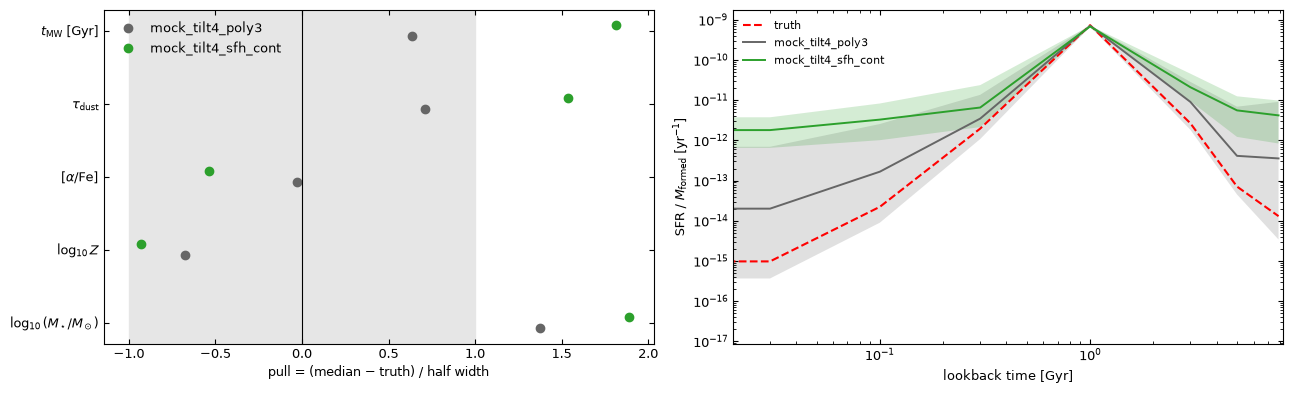

In [16]:
mocks = {a: fits[(a, "M5_172669")] for a in (MOCK_REF, MOCK_ARM) if (a, "M5_172669") in fits}
if mocks:
    any_fit = next(iter(mocks.values())); truth = any_fit["truth"]; lb = any_fit["sfh"]["lookback_time_gyr"]
    h = 10.0 ** np.concatenate([[0.0], -np.cumsum(truth["logsfr_ratios"])])
    m = 0.5 * (h[:-1] + h[1:]) * np.diff(lb)
    truth_values = {"logmass": truth["logmass"][0], "Z": truth["Z"][0], "afe": truth["afe"][0], "tau_dust": truth["diffuse_tau_kc"][0],
                    "age": float((m * 0.5 * (lb[:-1] + lb[1:])).sum() / m.sum())}
    pulls = pd.DataFrame([{"arm": a, **{k: (table.loc[("M5_172669", a), f"{k}_q50"] - v) / table.loc[("M5_172669", a), f"{k}_hw"] for k, v in truth_values.items()},
                           **{f"{k}_hw": table.loc[("M5_172669", a), f"{k}_hw"] for k in truth_values}} for a in mocks]).set_index("arm")
    pulls.to_csv(RESULTS / "mock-pulls.csv")
    display(pulls.round(2))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for i, name in enumerate(truth_values):
        for j, a in enumerate(mocks):
            axes[0].plot(pulls.loc[a, name], i + 0.15 * (j - 0.5), "o", color=COLOURS[a], label=a if i == 0 else None)
    axes[0].axvspan(-1, 1, color="0.9"); axes[0].axvline(0, color="k", lw=0.8)
    axes[0].set_yticks(range(len(truth_values))); axes[0].set_yticklabels([LABELS[k] for k in truth_values])
    axes[0].set_xlabel("pull = (median $-$ truth) / half width"); axes[0].legend(frameon=False)
    w = np.concatenate([[0.5 * np.diff(lb)[0]], 0.5 * (np.diff(lb)[:-1] + np.diff(lb)[1:]), [0.5 * np.diff(lb)[-1]]]) * 1e9
    axes[1].plot(lb, h / np.sum(h * w), "r--", lw=1.5, label="truth")
    for a, fit in mocks.items():
        sfh = fit["sfh"]
        axes[1].plot(lb, sfh["normalized_sfr_q50"], color=COLOURS[a], lw=1.4, label=a)
        axes[1].fill_between(lb, sfh["normalized_sfr_q16"], sfh["normalized_sfr_q84"], color=COLOURS[a], alpha=0.2, lw=0)
    axes[1].set(xscale="log", yscale="log", xlabel="lookback time [Gyr]", ylabel=r"SFR / $M_{\rm formed}$ [yr$^{-1}$]")
    axes[1].set_xlim(0.02, lb[-1] * 1.05); axes[1].legend(frameon=False, fontsize=8)
    fig.tight_layout(); fig.savefig(RESULTS / "mock-sfh-prior.png", dpi=130); plt.show()

## Wiki figures

- Copy every PNG beside the wiki note.

In [17]:
WIKI_FIGURES.mkdir(parents=True, exist_ok=True)
for png in sorted(RESULTS.glob("*.png")):
    shutil.copy2(png, WIKI_FIGURES / png.name)
sorted(p.name for p in WIKI_FIGURES.glob("*.png"))

['chi2-M12_185653.png',
 'chi2-M12_98104.png',
 'chi2-M1_206545.png',
 'chi2-M4_108989.png',
 'chi2-M5_172669.png',
 'chi2-M5_173928.png',
 'corner-M12_185653.png',
 'corner-M12_98104.png',
 'corner-M1_206545.png',
 'corner-M4_108989.png',
 'corner-M5_172669.png',
 'corner-M5_173928.png',
 'lick-by-arm.png',
 'mock-sfh-prior.png',
 'parameters-shift.png',
 'sfh-continuity.png',
 'sfh-histories.png',
 'stage0_chi2_map.png',
 'stage0_lick_residuals.png',
 'stage0_prior_rails.png']